# Between-scanner, within-scanner and between-paradigm variability of FC matrices

In [7]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
library(ggplot2)
library(ggbeeswarm)
library(dplyr)
library(patchwork)
library(FSA)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

## Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on during the generalization sessions is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030). For the investigation of the paradigm influence, we keep only the generalization sessions using the Prisma scanner.

In [8]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths
from confounds import get_confounds

# Define filtering parameters
metric = "correlation"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-fc")
dataset_path = Path("/data/datasets/hcph-dataset")
fmriprep_rel_path = Path("/data/derivatives/hcph-fmriprep")
fmriprep_gen_path = Path("/data/derivatives/hcph-fmriprep-generalization")
confounds_path = dataset_path / "phenotype" / "mood_env_quest.tsv"

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration \'hcph\' already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)

# Define entities common to all files
entities_base = {
    "subject": "001",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}
')

In [9]:
py_run_string('
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

## Load FC matrices for the generalization sessions
entities_base_gen = {
    **entities_base,
    "task": "rest",
}
# Get functional connectivity files
files_gen = layout.get(**entities_base_gen, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_gen) == 36, f"Expected 36 FC matrices, got {len(files_gen)}"
df_fc = pd.DataFrame({"filename": files_gen, "subject": "001"})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)

## Load confounds
confounds_df = get_confounds(dataset_path, confounds_path, confounds_of_interest=["slept_rest"])
# Keep only the magnitude part of functional scans and first echo
confounds_df = confounds_df[confounds_df["modality"] == "func"]
# Keep only the resting-state scans
confounds_df = confounds_df[confounds_df["task"].isin(["rest", "rsmovie"])]
# Drop columns that are not needed here
confounds_df = confounds_df.drop(columns=["filename", "modality", "task", "day_of_week", "time_of_day"])

# Merge the confounds in
df_fc = pd.merge(
        df_fc, confounds_df, on=["subject", "session"], how="inner"
    )

## Load FD estimates from fMRIPrep confounds
fmriprep_rel_layout = BIDSLayout(fmriprep_rel_path, config="hcph", indexer=_indexer, validate=False)
fmriprep_rel_entities = {
    "subject": "001",
    "desc": "confounds",
    "task": "rsmovie",
    "suffix": "timeseries",
    "extension": ".tsv",
}
fmriprep_rel_conf = fmriprep_rel_layout.get(**fmriprep_rel_entities, return_type="file")
assert len(fmriprep_rel_conf) == 36, f"Expected 36 fMRIPrep confounds files, got {len(fmriprep_rel_conf)}"

fmriprep_gen_layout = BIDSLayout(fmriprep_gen_path, config="hcph", indexer=_indexer, validate=False)
fmriprep_gen_entities = {
    "subject": "001",
    "desc": "confounds",
    "task": "rest",
    "suffix": "timeseries",
    "extension": ".tsv",
}
fmriprep_gen_conf = fmriprep_gen_layout.get(**fmriprep_gen_entities, return_type="file")
assert len(fmriprep_gen_conf) == 36, f"Expected 36 fMRIPrep confounds files, got {len(fmriprep_gen_conf)}"

fmriprep_df = pd.DataFrame({"filename": fmriprep_gen_conf + fmriprep_rel_conf, "subject": "001"})
fmriprep_df["session"] = fmriprep_df["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)
# Extract the mean FD from the fMRIPrep confounds files
def compute_fd_mean(tsv_file):
    df = pd.read_csv(tsv_file, sep="\t")
    return df["framewise_displacement"].mean()

fmriprep_df["fd_mean"] = fmriprep_df["filename"].apply(compute_fd_mean)
fmriprep_df = fmriprep_df.drop(columns=["filename"])

# Merge the confounds in
df_fc = pd.merge(
        df_fc, fmriprep_df, on=["subject", "session"], how="inner"
    )

## Load FC matrices from the reliability sessions
entities_base_rel = {
    **entities_base,
    "task": "rsmovie",
}
files_rel = layout.get(**entities_base_rel, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_rel) == 36, f"Expected 36 FC matrices, got {len(files_rel)}"
df_rsmovie = pd.DataFrame({"filename": files_rel, "task": "rsmovie", "subject": "001"})
df_rsmovie["session"] = df_rsmovie["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)
df_rsmovie["repetition"] = df_rsmovie.index + 1
# Merge the confounds in
df_rsmovie = pd.merge(df_rsmovie, confounds_df, on=["subject", "session"], how="inner")
df_rsmovie = pd.merge(df_rsmovie, fmriprep_df, on=["subject", "session"], how="inner")

# Keep only the session with prisma scanner for investigation of paradigm influence
df_fc_paradigm = df_fc[df_fc["scanner"] == "prisma"]
df_fc_paradigm = df_fc_paradigm.drop(columns=["scanner"])
df_fc_paradigm["task"] = "rest"
assert len(df_fc_paradigm) == 12, f"Expected 12 FC matrices for prisma scanner, got {len(df_fc_paradigm)}"

## Concatenate the two dataframes
df_fc_paradigm = pd.concat([df_fc_paradigm, df_rsmovie], ignore_index=True)
assert len(df_fc_paradigm) == 48, f"Expected 48 FC matrices after concatenation, got {len(df_fc_paradigm)}"
')

In [10]:
## Helper function to load the FC matrices from the file paths
load_fc_matrices <- function(df) {
    # Load all FC matrices and add the upper triangle flattened to the dataframe.
    # Since the FC matrix is symmetric, retaining only the upper triangle is sufficient.
    for (i in seq_len(nrow(df))) {
        tsv_file <- df$filename[i]
        mat <- as.matrix(read.table(tsv_file, header = FALSE, sep = "\t"))
        if (grepl("sparseinversecovariance", tsv_file)) {
            # Negate the precision matrix to get partial correlations
            mat <- -mat
        }
        # Flatten the upper triangle of the matrix (excluding diagonal)
        flat <- mat[upper.tri(mat, diag = FALSE)]
        col_names <- paste0("edge", seq_along(flat))
        # Add values to the dataframe
        for (j in seq_along(flat)) {
            df[i, col_names[j]] <- flat[j]
        }
    }
    # Remove the filename column as it is no longer needed
    df$filename <- NULL
    return(df)
}

In [ ]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)
df_fc <- load_fc_matrices(df_fc)
stopifnot(nrow(df_fc) == 36) #assert statement

col_names <- colnames(df_fc)
#Remove non-iqms column names
edge_keys <- col_names[grepl("^edge", col_names)]
if (any(!grepl("^edge", edge_keys))) {
    stop("All elements in edge_keys must contain 'edge'")
}

df_rsmovie <- as.data.frame(py$df_rsmovie)
df_rsmovie <- load_fc_matrices(df_rsmovie)
stopifnot(nrow(df_rsmovie) == 36)

df_fc_paradigm <- as.data.frame(py$df_fc_paradigm)
df_fc_paradigm <- load_fc_matrices(df_fc_paradigm)
stopifnot(nrow(df_fc_paradigm) == 48)
head(df_fc)

,subject,session,scanner,repetition,acq_time,pe_dir,slept_rest,fd_mean,edge1,edge2,⋯,edge1882,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,001,20101060,prisma,1,2024-08-20T21:19:11.542500,AP,Yes,0.09063796,0.2827941,0.3701252,⋯,0.1730595,0.3102559,0.2121344,0.2031167,0.4770941,0.2953542,0.1642162,0.4734638,0.4889089,0.3620068
2,001,20102030,vidafit,1,2024-08-20T22:59:30.355000,RL,No,0.09772856,0.2989734,0.4257047,⋯,0.5119642,0.4776001,0.4571604,0.4440488,0.6165075,0.3442986,0.4719748,0.3867397,0.4178769,0.5189680
3,001,20103034,vida,1,2024-08-21T00:32:54.322500,PA,No,0.09289577,0.5496409,0.6378708,⋯,0.6684356,0.4696130,0.5322509,0.4993899,0.7612367,0.5316175,0.5145998,0.5403605,0.6864804,0.5960710
4,001,20201060,prisma,2,2024-08-21T20:51:59.287500,RL,Yes,0.10522386,0.2171777,0.5192892,⋯,0.4358424,0.4371684,0.2114518,0.3034416,0.4864878,0.3020995,0.4284669,0.3970554,0.5058466,0.4216522
5,001,20202030,vidafit,2,2024-08-21T22:23:23.142500,AP,No,0.08670034,0.5146798,0.4826543,⋯,0.6440360,0.5486310,0.5267422,0.4705275,0.6739694,0.5031739,0.4826841,0.5139879,0.5398819,0.5300936
6,001,20203034,vida,2,2024-08-22T00:04:15.010000,RL,No,0.12199567,0.5096338,0.6318354,⋯,0.6452073,0.5660315,0.5724041,0.4610906,0.6353785,0.5021469,0.5146907,0.4986800,0.5097432,0.6179405


Note that if you already computed and saved the ICC in a table, you can directly jump to the section "Visualize the ICC results".

## Intra-class correlation coefficient (ICC) to quantify between-scanner variability

In [12]:
icc_between <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept = numeric(), fd_mean = numeric(), fd_diff = numeric(), stringsAsFactors = FALSE)

scanners <- unique(df_fc$scanner)
# Iterate over the three possible scanner pairs
for (i in 1:2) {
  for (j in (i + 1):3) {

    # Iterate over all possible pairs of repetition
    for (rep1 in 1:12) {
      for (rep2 in 1:12) {
        sc1 <- scanners[i]
        sc2 <- scanners[j]

        # Extract that permutation of repetitions
        df_rep <- rbind(subset(df_fc, scanner == sc1 & repetition == rep1), subset(df_fc, scanner == sc2 & repetition == rep2))

        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
          if (any(is.na(df_rep$slept))) {
              # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
              slept <- NA
          } else {
              df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
              slept <- sum(df_rep$slept)
          }
        # Indicate mean and difference of FD between the two repetitions
        fd_mean <- mean(df_rep$fd_mean)
        fd_diff <- abs(diff(df_rep$fd_mean))

        # Keep only the edge column and transpose the dataframe
        col_names <- df_rep$scanner
        df_edges <- t(df_rep[, edge_keys])  # rows: edges, cols: scanners
        colnames(df_edges) <- col_names

        # Compute average edge strength between the two repetitions
        avg_strength <- rowMeans(df_edges, na.rm = TRUE)

        # Compute ICC(2,1)
        icc_val <- icc(df_edges, model = "twoway", type = "agreement", unit = "single")$value

        # Store the results
        icc_between <- rbind(
            icc_between,
            data.frame(
            variability_type = "between-scanner",
            task = "rest",
            scanner = paste0(scanners[i], "-", scanners[j]),
            repetition = paste0(rep1, "-", rep2),
            ICC = icc_val,
            summary_statistic = NA,
            days_diff = NA,
            slept = slept,
            fd_mean = fd_mean,
            fd_diff = fd_diff
            )
        )  
      }
    }
  }
}

head(df_rep)
head(icc_between)

ERROR: Error in eval(expr, envir, enclos): object 'edge_keys' not found


In [ ]:
mean_icc <- mean(icc_between$ICC, na.rm = TRUE)
cat("Mean bootstraped between-scanner ICC:", mean_icc, "\n")
quantiles <- quantile(icc_between$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_between <- rbind(
    icc_between,
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA)
)

Mean bootstraped between-scanner ICC: 0.5880701 
Quantiles (25%, median, 75%): 0.4041885 0.5555581 0.8016743 


## ICC to quantify within-scanner variability when using standard resting-state

Let's quantify the within-scanner reliability of FC estimates when using the standard fixation cross task for resting-state.

### Using all 12 sessions

In [ ]:
icc_within_rest <- list()
for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    df_scanner <- t(df_scanner[, edge_keys])
    icc_within_rest[[scanner]] <- icc(df_scanner, model = "twoway", type = "agreement", unit = "single")$value
    cat(sprintf("Within-scanner ICC for %s scanner: %.4f\n", scanner, icc_within_rest[[scanner]]))
}
head(df_scanner)

Within-scanner ICC for prisma scanner: 0.5600
Within-scanner ICC for vidafit scanner: 0.5330
Within-scanner ICC for vida scanner: 0.6345


,3,6,8,11,14,16,19,23,27,30,31,35
edge1,0.5496409,0.5096338,0.4131504,0.4449821,0.4811377,0.4517719,0.14202430,0.4132667,0.6015462,0.4562355,0.4532706,0.3348681
edge2,0.6378708,0.6318354,0.3158849,0.5041109,0.5994747,0.5578053,0.58822103,0.5496495,0.6282911,0.4788228,0.5092740,0.3999343
edge3,0.6992454,0.6954506,0.7255366,0.7121464,0.6295779,0.8051219,0.15598399,0.7147821,0.7653149,0.6726379,0.7430331,0.6203486
edge4,0.7256449,0.7096535,0.6781975,0.7078274,0.7546007,0.7273291,0.74348573,0.6888926,0.6716462,0.6576057,0.6938245,0.6305883
edge5,0.4162345,0.3095280,0.3174185,0.3909103,0.3908073,0.4687818,0.08717465,0.4091270,0.4564391,0.3178301,0.2573947,0.1123629
edge6,0.5537715,0.4565463,0.3077499,0.4390451,0.5227392,0.5188716,0.59198707,0.4663180,0.4230545,0.2656652,0.2658177,0.1841879


### Bootstrap all possible pairs of repetitions

In [ ]:
icc_intra_rest <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept = numeric(), fd_mean = numeric(), fd_diff = numeric(), stringsAsFactors = FALSE)

for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    # Iterate over all possible pairs of repetition
    for (rep1 in 1:11) {
      # Ensure rep2 is always greater than rep1 to avoid duplicates
      for (rep2 in (rep1+1):12) {

            # Extract that permutation of repetitions
            df_rep <- rbind(subset(df_scanner, repetition == rep1), subset(df_scanner, repetition == rep2))
            # Compute how many days apart the two repetitions are
            days_diff <- as.numeric(abs(as.Date(df_rep$acq_time[1]) - as.Date(df_rep$acq_time[2])))
            # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
            if (any(is.na(df_rep$slept))) {
                # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
                slept <- NA
            } else {
                df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
                slept <- sum(df_rep$slept)
            }
            # Indicate mean and difference of FD between the two repetitions
            fd_mean <- mean(df_rep$fd_mean)
            fd_diff <- abs(diff(df_rep$fd_mean))

            #Keep only the edge column and transpose the dataframe
            df_rep <- t(df_rep[, edge_keys])

            # Compute ICC(2,1)
            icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
            icc_intra_rest <- rbind(icc_intra_rest, data.frame(variability_type = "within-scanner", task="rest", scanner=scanner, repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept=slept, fd_mean = fd_mean, fd_diff = fd_diff))
        }
    }
}
head(df_rep)
head(icc_intra_rest)

,31,35
edge1,0.4532706,0.3348681
edge2,0.5092740,0.3999343
edge3,0.7430331,0.6203486
edge4,0.6938245,0.6305883
edge5,0.2573947,0.1123629
edge6,0.2658177,0.1841879


,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,fd_mean,fd_diff
,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
1,within-scanner,rest,prisma,1-2,0.8104636,NA,1,2,0.09793091,0.014585896
2,within-scanner,rest,prisma,1-3,0.7115025,NA,2,2,0.10494360,0.028611282
3,within-scanner,rest,prisma,1-4,0.4187486,NA,3,1,0.10588899,0.030502054
4,within-scanner,rest,prisma,1-5,0.4241301,NA,4,1,0.10761685,0.033957771
5,within-scanner,rest,prisma,1-6,0.7735494,NA,5,2,0.08815805,0.004959817
6,within-scanner,rest,prisma,1-7,0.5158890,NA,7,1,0.10644679,0.031617660


In [ ]:
for (scanner in unique(df_fc$scanner)) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    mean_icc <- mean(icc_intra_rest_scanner$ICC, na.rm = TRUE)
    cat("Scanner:", scanner, "\n")
    cat("Mean bootstraped within-scanner ICC:", mean_icc, "\n")
    quantiles <- quantile(icc_intra_rest_scanner$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
    cat("Quantiles (25%, median, 75%):", quantiles, "\n")

    icc_intra_rest <- rbind(
        icc_intra_rest,
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = slept, fd_mean = NA, fd_diff = NA),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = slept, fd_mean = NA, fd_diff = NA),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = slept, fd_mean = NA, fd_diff = NA),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = slept, fd_mean = NA, fd_diff = NA)
    )
}

Scanner: prisma 
Mean bootstraped within-scanner ICC: 0.5652956 
Quantiles (25%, median, 75%): 0.387248 0.4742039 0.7801331 
Scanner: vidafit 
Mean bootstraped within-scanner ICC: 0.5592037 
Quantiles (25%, median, 75%): 0.3009559 0.570787 0.8095756 
Scanner: vida 
Mean bootstraped within-scanner ICC: 0.6447866 
Quantiles (25%, median, 75%): 0.5280224 0.6745361 0.7960005 


## ICC to quantify within-scanner variability when using naturalistic movie

### Using all 36 sessions

In [ ]:
df_intra_rsmovie <- t(df_rsmovie[, edge_keys])
head(df_intra_rsmovie)
icc_val_intra_rsmovie <- icc(df_intra_rsmovie, model = "twoway", type = "agreement", unit = "single")$value
cat(sprintf("Within-scanner ICC for rsmovie: %.4f\n", icc_val_intra_rsmovie))

edge1,0.6216386,0.6403972,0.5412989,0.5346348,0.6104283,0.6035920,0.4466778,0.5050477,0.5457476,0.4679785,⋯,0.4544409,0.5153529,0.5399256,0.5702904,0.5435963,0.4820986,0.3642394,0.4611147,0.5162571,0.3266557
edge2,0.5941284,0.6621736,0.5264868,0.5345418,0.5184101,0.5604684,0.4374828,0.5460433,0.5107944,0.4278021,⋯,0.4923441,0.5952549,0.5841836,0.6445598,0.5662279,0.5802214,0.5269814,0.6362241,0.6555242,0.4594529
edge3,0.7133108,0.6845539,0.5850952,0.7297089,0.6750612,0.7381508,0.5461094,0.6531540,0.6263609,0.5706040,⋯,0.6516860,0.6295478,0.7052182,0.6908451,0.7591276,0.6104920,0.4961447,0.6615232,0.6219265,0.5014879
edge4,0.7408829,0.7714371,0.7457973,0.7591273,0.7632487,0.7389312,0.7470424,0.7875297,0.7609913,0.7715509,⋯,0.7342332,0.7985510,0.6935204,0.6814568,0.7530195,0.6772000,0.6578069,0.6618083,0.6505799,0.6379796
edge5,0.5368403,0.4925515,0.4392278,0.4969488,0.5269248,0.4902849,0.3974737,0.4672775,0.3960080,0.3813823,⋯,0.2556588,0.4521184,0.3283802,0.5248521,0.4698423,0.4506773,0.3867090,0.4423098,0.3995207,0.3442520
edge6,0.5454009,0.5587658,0.4729301,0.4852340,0.5158932,0.5434923,0.3848835,0.4091123,0.2955827,0.2487566,⋯,0.2095474,0.3972067,0.3930193,0.4314876,0.5344769,0.4469067,0.3842306,0.5614531,0.4758118,0.3496748


Within-scanner ICC for rsmovie: 0.7783


### Bootstrap to permute through all possible pairs of repetitions

In [ ]:
icc_intra_rsmovie <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(),slept = numeric(),fd_mean=numeric(), fd_diff = numeric(), stringsAsFactors = FALSE)

# Iterate over all possible pairs of repetition
for (rep1 in 1:35) {
  # Ensure rep2 is always greater than rep1 to avoid duplicates
  for (rep2 in (rep1+1):36) {

        # Extract that permutation of repetitions
        df_rep <- rbind(subset(df_rsmovie, repetition == rep1), subset(df_rsmovie, repetition == rep2))
        # Compute how many days apart the two repetitions are
        days_diff <- as.numeric(abs(as.Date(df_rep$acq_time[1]) - as.Date(df_rep$acq_time[2])))
        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
            if (any(is.na(df_rep$slept))) {
                # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
                slept <- NA
            } else {
                df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
                slept <- sum(df_rep$slept)
            }
        # Indicate mean and difference of FD between the two repetitions
        fd_mean <- mean(df_rep$fd_mean)
        fd_diff <- abs(diff(df_rep$fd_mean))
        
        #Keep only the edge column and transpose the dataframe
        df_rep <- t(df_rep[, edge_keys])

        # Compute ICC(2,1)
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_intra_rsmovie <- rbind(icc_intra_rsmovie, data.frame(variability_type = "within-scanner", task="rsmovie", scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept=slept, fd_mean = fd_mean, fd_diff = fd_diff))
    }
}
head(df_rep)
head(icc_intra_rsmovie)

In [ ]:
mean_icc <- mean(icc_intra_rsmovie$ICC, na.rm = TRUE)
cat("Mean bootstraped within-scanner ICC:", mean_icc, "\n")
quantiles <- quantile(icc_intra_rsmovie$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_intra_rsmovie <- rbind(
    icc_intra_rsmovie,
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA)
)

Mean bootstraped within-scanner ICC across edges: 0.7829362 
Quantiles (25%, median, 75%): 0.7299645 0.8061051 0.8455674 


## ICC to quantify variability across paradigms

In [ ]:
icc_paradigm <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept= numeric(),fd_mean=numeric(), fd_diff=numeric(), stringsAsFactors = FALSE)

# Iterate over all possible combinations of repetition numbers for the 3 scanners
tasks <- unique(df_fc_paradigm$task)
for (rep1 in 1:12) {
  for (rep2 in 1:36) {

        # Extract that permutation of repetitions
        reps <- c(rep1, rep2)
        df_rep <- data.frame()
        for (i in 1:2) {
          df_one <- subset(df_fc_paradigm, task == tasks[i] & repetition == reps[i])
          df_rep <- rbind(df_rep, df_one)
        }
        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
        if (any(is.na(df_rep$slept))) {
            # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
            slept <- NA
        } else {
            df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
            slept <- sum(df_rep$slept)
        }
        # Indicate mean and difference of FD between the two repetitions
        fd_mean <- mean(df_rep$fd_mean)
        fd_diff <- abs(diff(df_rep$fd_mean))
        
        # Keep only the edge column and transpose the dataframe
        colnames <- df_rep$task
        df_rep <- t(df_rep[, edge_keys])
        colnames(df_rep) <- colnames
        # Compute ICC(2,1) for this edge
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_paradigm <- rbind(icc_paradigm, data.frame(variability_type = "between-paradigm", task=NA, scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept = slept, fd_mean = fd_mean, fd_diff = fd_diff))
    }
}
head(df_rep)
head(icc_paradigm)

,rest,rsmovie
edge1,0.3995341,0.3266557
edge2,0.4532716,0.4594529
edge3,0.7270787,0.5014879
edge4,0.7265083,0.6379796
edge5,0.3396650,0.3442520
edge6,0.3066537,0.3496748


,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,fd_mean,fd_diff
,<chr>,<lgl>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
1,between-paradigm,NA,prisma,1-1,0.4166026,NA,0,NA,0.10121699,0.0211580633
2,between-paradigm,NA,prisma,1-2,0.4740292,NA,0,NA,0.09103153,0.0007871362
3,between-paradigm,NA,prisma,1-3,0.4793847,NA,0,1,0.11468140,0.0480868728
4,between-paradigm,NA,prisma,1-4,0.4170954,NA,0,1,0.09766865,0.0140613714
5,between-paradigm,NA,prisma,1-5,0.3687580,NA,0,1,0.08465956,0.0119568048
6,between-paradigm,NA,prisma,1-6,0.5041669,NA,0,1,0.09321756,0.0051591886


In [ ]:
mean_icc <- mean(icc_paradigm$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_paradigm$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_paradigm <- rbind(
    icc_paradigm,
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA, fd_mean = NA, fd_diff = NA)
)

Mean ICC across edges: 0.5649815 
Quantiles (25%, median, 75%): 0.40602 0.5326702 0.7256168 


## Save the ICC estimates in a table

We use pybids to determine the filename to save the table.

In [ ]:
py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'tables',
    'suffix': 'bold',
    'desc': 'icc'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")

In [ ]:
icc_results <- rbind(icc_between, icc_paradigm, icc_intra_rsmovie, icc_intra_rest)

write.table(icc_results, file = py$save_path, sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)

## Visualize the ICC results

Load all the ICC computed for both connectivity measure: correlation and sparse inverse covariance.

In [ ]:
py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'tables',
    'suffix': 'bold',
    'desc': 'icc'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")

# Extract the measurement type from the filename
meas <- sub(".*meas-([a-zA-Z]+).*", "\\1", py$save_path)

# Determine the alternate measurement type
alt_meas <- ifelse(meas == "sparseinversecovariance", "correlation", "sparseinversecovariance")

# Construct the alternate file path
alt_save_path <- gsub(meas, alt_meas, py$save_path)

if (file.exists(py$save_path) && file.exists(alt_save_path)) {
    # Read the saved ICC results for both measurement types
    icc_results_1 <- read.table(py$save_path, sep = "\t", header = TRUE, stringsAsFactors = FALSE)
    icc_results_1$meas <- meas
    icc_results_2 <- read.table(alt_save_path, sep = "\t", header = TRUE, stringsAsFactors = FALSE)
    icc_results_2$meas <- alt_meas

    # Combine the results into a single data frame
    icc_combined <- rbind(icc_results_1, icc_results_2)
    head(icc_combined)
} else {
    cat("The following files must exist at the specified paths:\n")
    cat(py$save_path, "\n")
    cat(alt_save_path, "\n")
    cat("Please run the upper part of the notebook to compute the ICC first.")
}

,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,fd_mean,fd_diff,meas
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>
1,between-scanner,rest,prisma-vidafit,1-1,0.4202737,NA,NA,1,0.09418326,0.007090599,correlation
2,between-scanner,rest,prisma-vidafit,1-2,0.4522678,NA,NA,1,0.08866915,0.003937620,correlation
3,between-scanner,rest,prisma-vidafit,1-3,0.4727037,NA,NA,1,0.10118656,0.021097199,correlation
4,between-scanner,rest,prisma-vidafit,1-4,0.8813157,NA,NA,2,0.10962003,0.037964134,correlation
5,between-scanner,rest,prisma-vidafit,1-5,0.6174093,NA,NA,2,0.10269284,0.024109755,correlation
6,between-scanner,rest,prisma-vidafit,1-6,0.4560231,NA,NA,1,0.10157006,0.021864191,correlation


Separate variability types into their standalone dataframes and prepare the dataframes for plotting.

In [ ]:
# Convert the 'slept' column to a factor with appropriate labels
icc_combined$slept_factor <- factor(
    ifelse(is.na(icc_combined$slept), -1, icc_combined$slept),
    levels = c(0, 1, 2, -1),
    labels = c("Slept in no session", "Slept in one session", "Slept in both sessions", "Unknown")
)
# Within-scanner with naturalistic movie
icc_intra_rsmovie <- icc_combined[icc_combined$variability_type == "within-scanner" & icc_combined$meas == meas & icc_combined$task == "rsmovie", ]

# Within-scanner with standard resting-state
icc_intra_rest <- icc_combined[icc_combined$variability_type == "within-scanner" & icc_combined$meas == meas & icc_combined$task == "rest", ]

# Between-scanner
icc_between <- icc_combined[icc_combined$variability_type == "between-scanner" & icc_combined$meas == meas, ]
icc_between$scanner_factor <- factor(
    icc_between$scanner,
    levels = c("prisma-vida", "prisma-vidafit", "vidafit-vida"),
    labels = c("Prisma - Vida", "Prisma - VidaFit", "Vida - VidaFit")
)

# Between-paradigm
icc_paradigm <- icc_combined[icc_combined$variability_type == "between-paradigm" & icc_combined$meas == meas, ]

# Filter only the bootstrap/permutation ICCs (exclude summary statistics)
df_plot <- icc_combined %>%
    filter(is.na(summary_statistic)) %>%
    mutate(
        variability_plotname = case_when(
            variability_type == "within-scanner" & task == "rsmovie" ~ "Within-scanner (rsmovie, prisma)",
            variability_type == "within-scanner" & task == "rest" & scanner == "prisma" ~ "Within-scanner (rest, prisma)",
            variability_type == "within-scanner" & task == "rest" & scanner == "vida" ~ "Within-scanner (rest, vida)",
            variability_type == "within-scanner" & task == "rest" & scanner == "vidafit" ~ "Within-scanner (rest, vidafit)",
            variability_type == "between-scanner" ~ "Between-scanner (rest)",
            variability_type == "between-paradigm" ~ "Between-paradigm (prisma)",
            TRUE ~ NA_character_
        )
    )

# Set factor order for plot
df_plot$meas <- factor(df_plot$meas, levels = c("sparseinversecovariance", "correlation"), labels = c("Sparse Inverse Covariance", "Correlation"))
df_plot$variability_plotname <- factor(df_plot$variability_plotname, levels = c(
    "Within-scanner (rsmovie, prisma)",
    "Within-scanner (rest, vida)",
    "Within-scanner (rest, vidafit)",
    "Within-scanner (rest, prisma)",    
    "Between-scanner (rest)",
    "Between-paradigm (prisma)"
))

#### Compare ICC across variability type and across connectivity measure

In [ ]:
# Perform Wilcoxon signed-rank test to compare ICC distribution with sparseinversecovariance versus correlation for each variability type
# ICC distribution are clearly not normal, so we use this non-parametric test instead of a t-test
icc_significance <- df_plot %>%
    group_by(variability_plotname) %>%
    summarise(
        p_value = wilcox.test(ICC ~ meas, data = cur_data())$p.value
    ) %>%
    mutate(
        significance = case_when(
            p_value < 0.001 ~ "***",
            p_value < 0.01 ~ "**",
            p_value < 0.05 ~ "*",
            TRUE ~ "ns"
        )
    )

print(icc_significance)

# Merge significance data with the plot data
df_plot <- df_plot %>%
    left_join(icc_significance, by = "variability_plotname")

# A tibble: 6 × 3
  variability_plotname               p_value significance
  <fct>                                <dbl> <chr>       
1 Within-scanner (rsmovie, prisma) 2.27e-116 ***         
2 Within-scanner (rest, vida)      3.85e- 10 ***         
3 Within-scanner (rest, vidafit)   1.49e-  7 ***         
4 Within-scanner (rest, prisma)    1.56e-  7 ***         
5 Between-scanner (rest)           1.25e- 42 ***         
6 Between-paradigm (prisma)        4.12e- 67 ***         


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


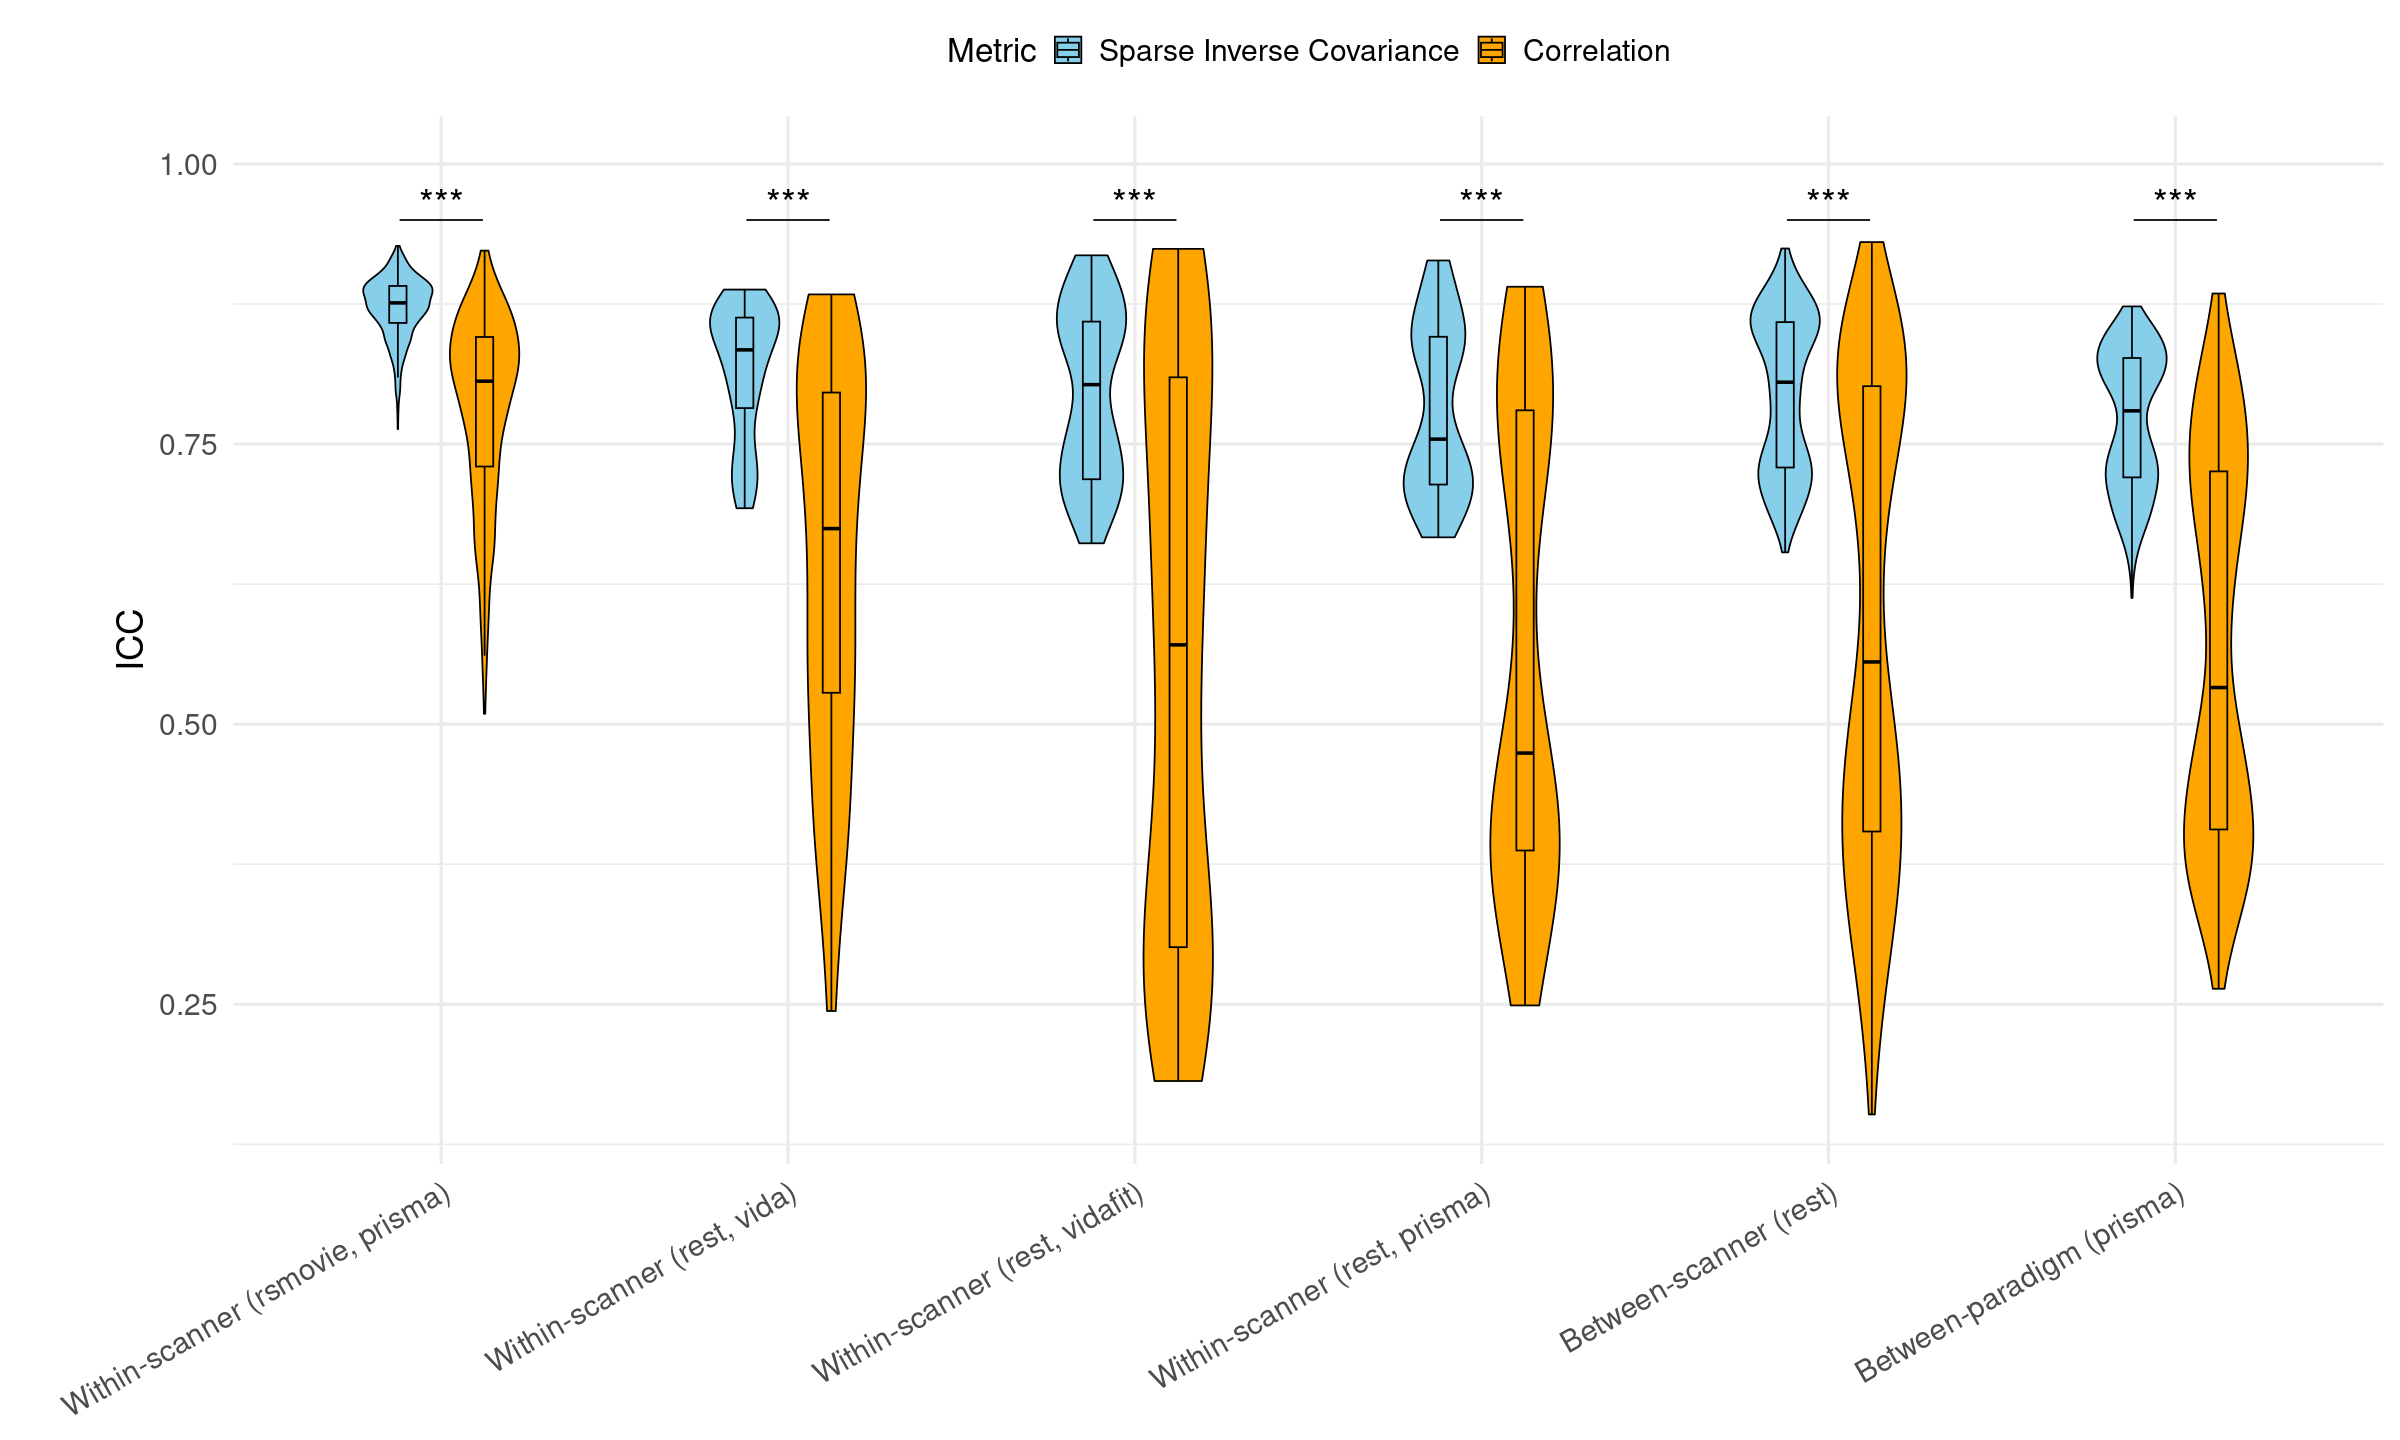

In [ ]:
options(repr.plot.height = 12)
options(repr.plot.width = 20)

ggplot(df_plot, aes(x = variability_plotname, y = ICC, fill = meas)) +
    geom_violin(trim = TRUE, position = position_dodge(width = 0.5), color = "black", width = 0.4, scale="width") +
    geom_boxplot(aes(fill = meas), width = 0.1, position = position_dodge(width = 0.5), outlier.shape = NA, color = "black") +
    geom_segment(
        data = icc_significance,
        aes(
            x = as.numeric(variability_plotname) - 0.12,
            xend = as.numeric(variability_plotname) + 0.12 ,
            y = 0.95,
            yend = 0.95
        ),
        inherit.aes = FALSE,
        size = 0.5,
        color = "black"
    ) +
    geom_text(
        data = icc_significance,
        aes(
            x = as.numeric(variability_plotname),
            y = 0.94,
            label = significance
        ),
        inherit.aes = FALSE,
        size = 8,
        vjust = -0.5,
    ) +
    theme_minimal(base_size = 20) +
    labs(x = NULL, y = "ICC", fill = "Metric") +
    theme(
        axis.text.x = element_text(angle = 30, hjust = 1, size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.y = element_text(size = 22),
        plot.title = element_text(size = 24, face = "bold"),
        legend.position = "top",
        legend.text = element_text(size = 18),  # Increase legend text size
        legend.title = element_text(size = 20), # Increase legend title size
        plot.margin = margin(t = 10, r = 10, b = 10, l = 70)
    ) +
    scale_fill_manual(values = c("skyblue", "orange")) +
    ylim(0.15, 1.0)

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'icccomparative',
}
entities.update(entities_base)
entities['measure'] = None
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300)


### Sleep influence on reliability

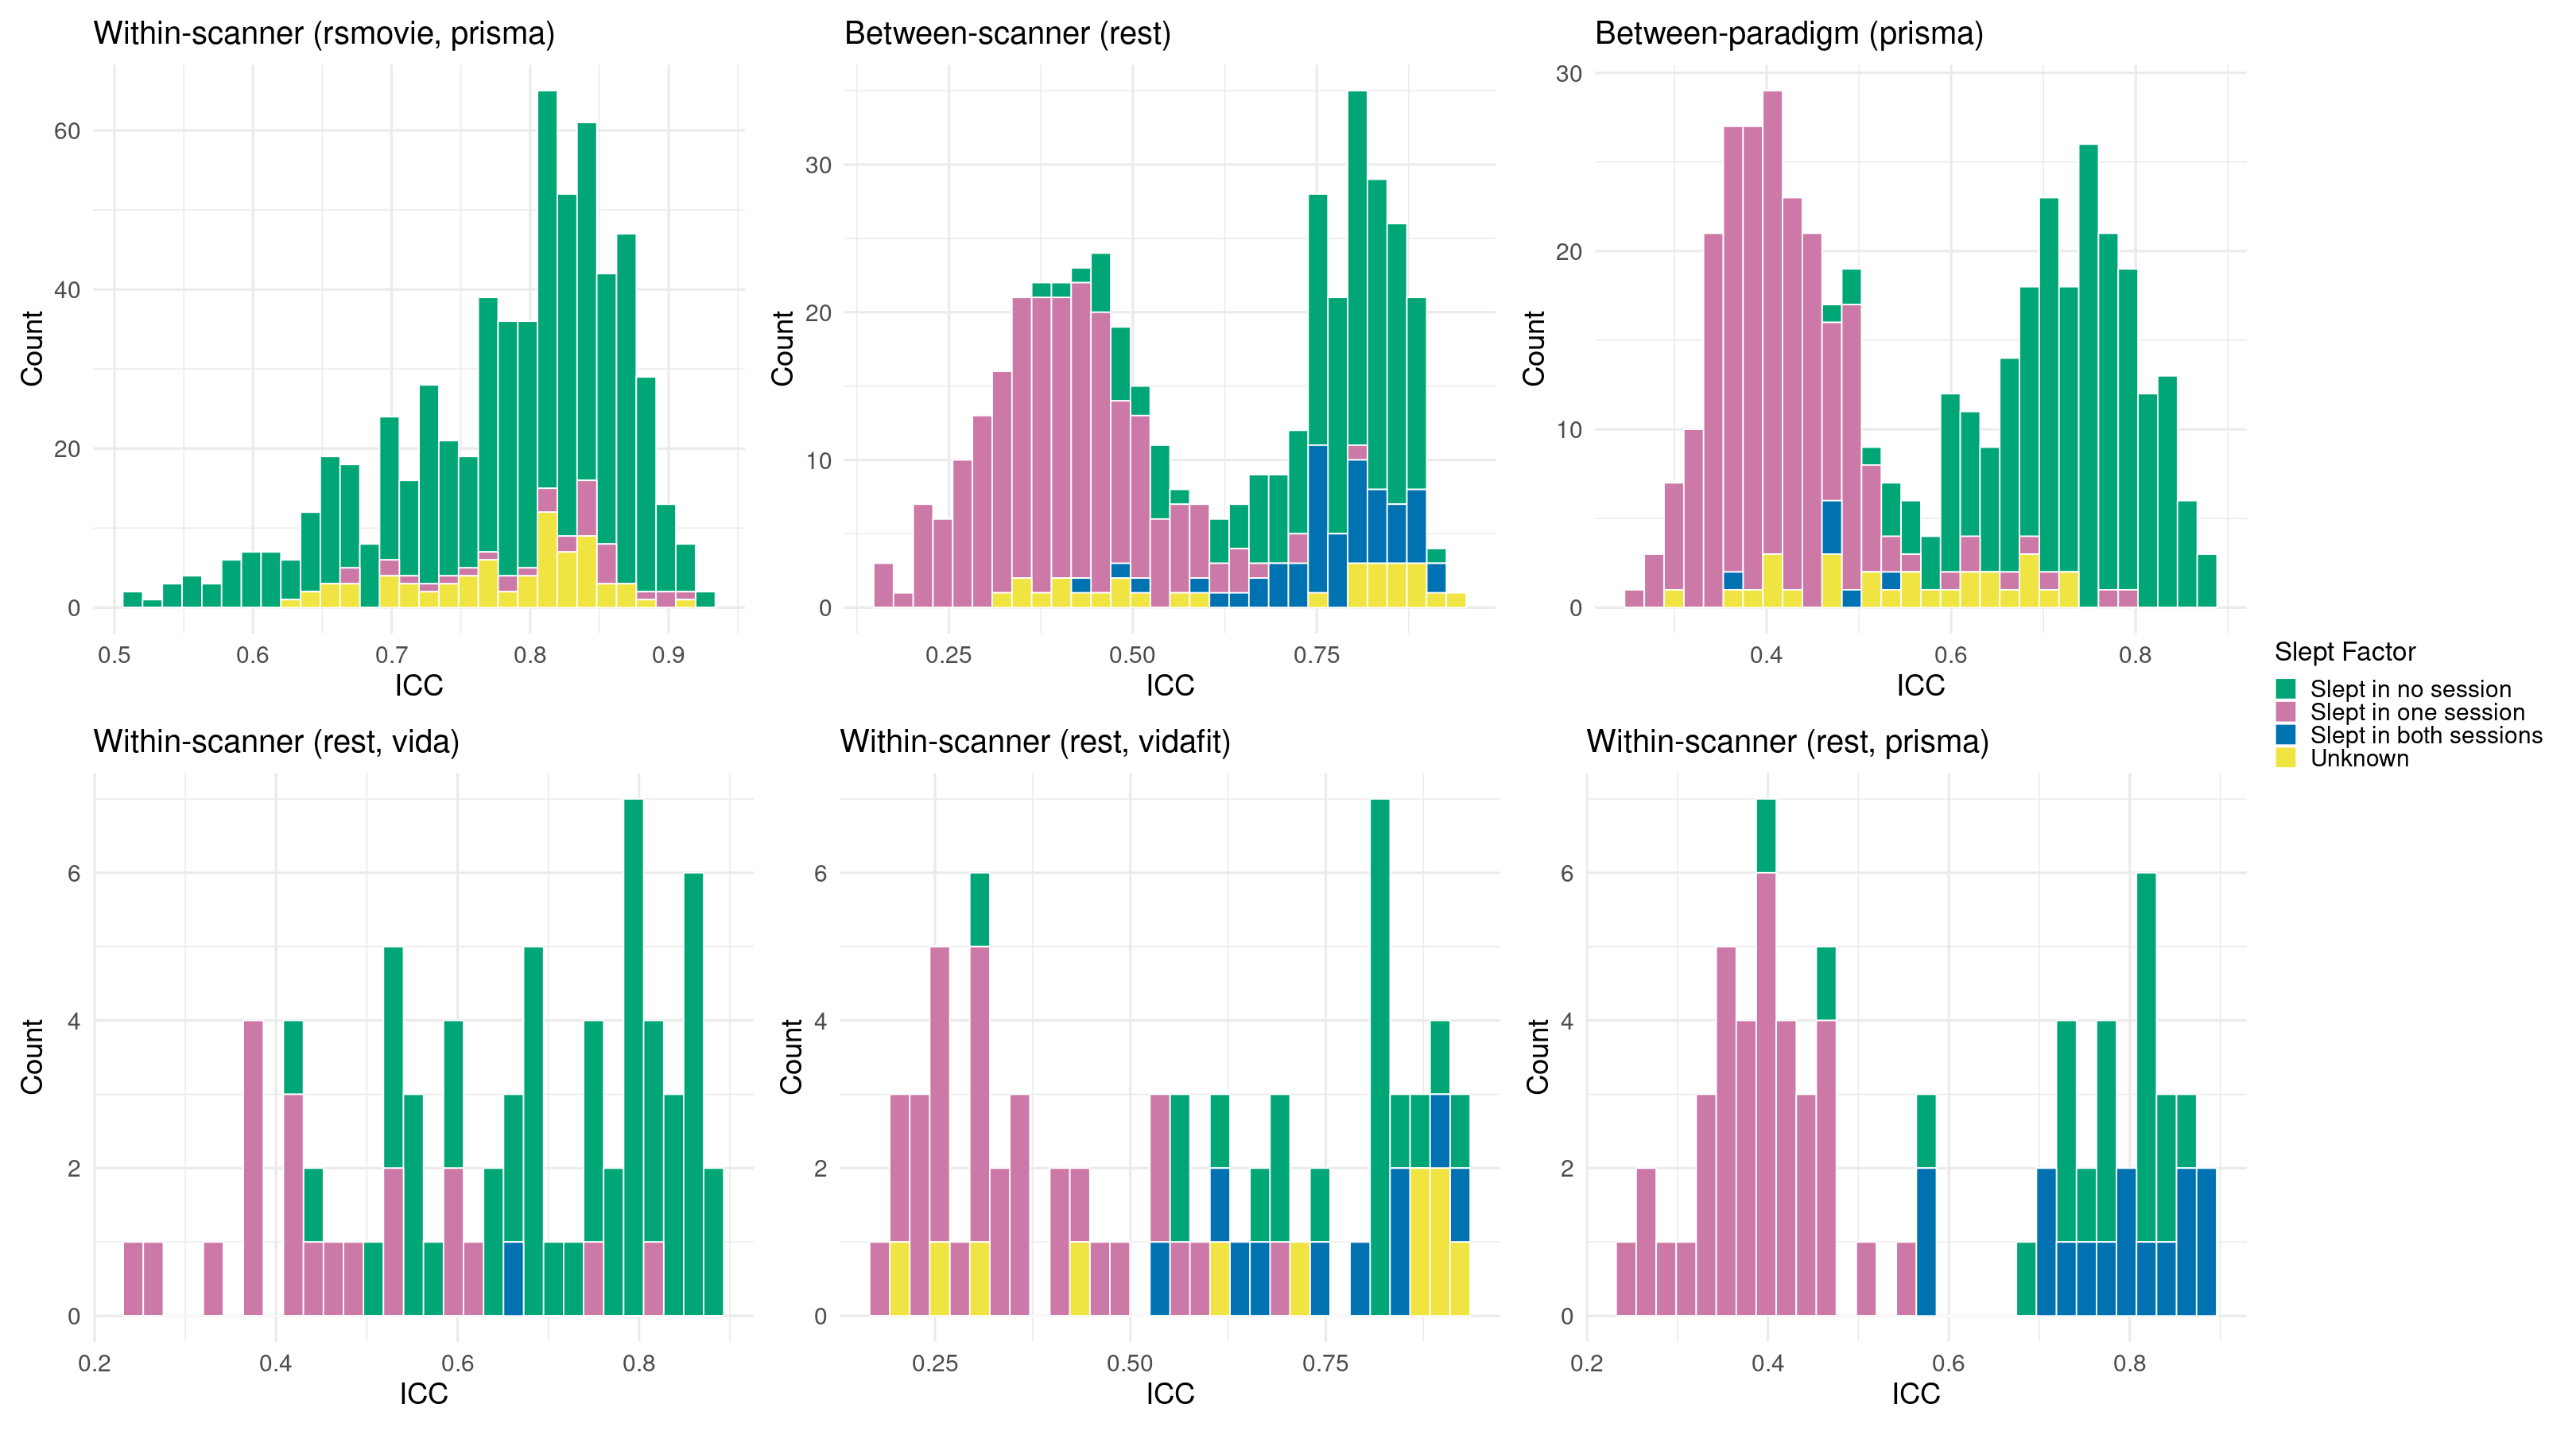

In [ ]:
options(repr.plot.width = 27, repr.plot.height = 15)
# Plot
plot_rsmovie <- ggplot(data = icc_intra_rsmovie, aes(x = ICC, fill = slept_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Slept Factor",
        title = "Within-scanner (rsmovie, prisma)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20),
        legend.position = "none" 
    ) +
    scale_fill_manual(values = c("#00A676", "#CC79A7", "#F0E442"))

plot_between <- ggplot(data = icc_between, aes(x = ICC, fill = slept_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Slept Factor",
        title = "Between-scanner (rest)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20),
        legend.position = "none" 
    ) +
    scale_fill_manual(values = c("#00A676", "#CC79A7", "#0072B2", "#F0E442"))

plot_paradigm <- ggplot(data = icc_paradigm, aes(x = ICC, fill = slept_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Slept Factor",
        title = "Between-paradigm (prisma)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20),
        legend.position = "right" 
    ) +
    scale_fill_manual(values = c("#00A676", "#CC79A7", "#0072B2", "#F0E442"))

# Create plots for each scanner
plots_scanners <- lapply(c("vida", "vidafit", "prisma"), function(scanner) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    title <- switch(
        scanner,
        "vida" = "Within-scanner (rest, vida)",
        "vidafit" = "Within-scanner (rest, vidafit)",
        "prisma" = "Within-scanner (rest, prisma)"
    )
    ggplot(data = icc_intra_rest_scanner, aes(x = ICC, fill = slept_factor)) +
        geom_histogram(color = 'white', bins = 30, position = "stack") +
        labs(
            x = "ICC",
            y = "Count",
            fill = "Sleep Factor",
            title = title
        ) +
        theme_minimal(base_size = 20) +
        theme(
            axis.text.x = element_text(size = 18),
            axis.text.y = element_text(size = 18),
            axis.title.x = element_text(size = 22),
            axis.title.y = element_text(size = 22),
            legend.text = element_text(size = 18),
            legend.title = element_text(size = 20),
            legend.position = "none"  # Hide legend for individual scanner plots
        ) +
        scale_fill_manual(values = c("#00A676", "#CC79A7", "#0072B2", "#F0E442"))
})

# Combine all plots into a single figure with one legend
combined_plot <- (plot_rsmovie | plot_between | plot_paradigm) / wrap_plots(plots_scanners, ncol = 3) +
    plot_layout(guides = "collect") 

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'iccVSsleep',
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300)

# Display the combined plot
print(combined_plot)

As we see in the figure above, the bimodal distribution of ICC values reflects two distinct regimes: ICC is higher when the participant either consistently stayed awake or consistently fell asleep across both sessions, compared to when the participant was awake in one session and asleep in the other.

#### Did our participant exhibit a consistent pattern of sleeping more in a specific scanner? 

In [ ]:
# Count occurrences of "Yes" and "No" for slept_rest for each scanner
print("Number of times the participant slept during the standard resting state session for each scanner:")
slept_counts <- df_fc %>%
    group_by(scanner) %>%
    summarise(
        slept_yes = sum(slept_rest == "Yes", na.rm = TRUE),
        slept_no = sum(slept_rest == "No", na.rm = TRUE)
    )

print(slept_counts)
cat("\n")

# Count occurrences of "Yes" and "No" for slept_rest in df_rsmovie
print("Number of times the participant slept during the naturalistic movie:")
slept_counts_rsmovie <- df_rsmovie %>%
    summarise(
        slept_yes = sum(slept_rest == "Yes", na.rm = TRUE),
        slept_no = sum(slept_rest == "No", na.rm = TRUE)
    )

print(slept_counts_rsmovie)

[1] "Number of times the participant slept during the standard resting state session for each scanner:"
# A tibble: 3 × 3
  scanner slept_yes slept_no
  <chr>       <int>    <int>
1 prisma          6        6
2 vida            2       10
3 vidafit         5        6

[1] "Number of times the participant slept during the naturalistic movie:"
  slept_yes slept_no
1         1       33


Two remarks about the numbers above:
1. Clearly the participant fell much less often asleep when the movie was playing. This is consistent with previous literature saying that playing a naturalistic movie helps remain awake. Interestingly, we showed in the figure above that sleeping leads to less reliable estimation of FC, hence using naturalistic movie can help obtaining more reliable estimate by preventing the participant to fall asleep.
2. The participant fell asleep less in the vida than the prisma and vidafit. Paired with the observation that sleeping reduces FC reliability, this could explain why vida shows remarkably higher ICC than prisma and vidafit.

#### Is there a scanner that is systematically less reliable than the other two?

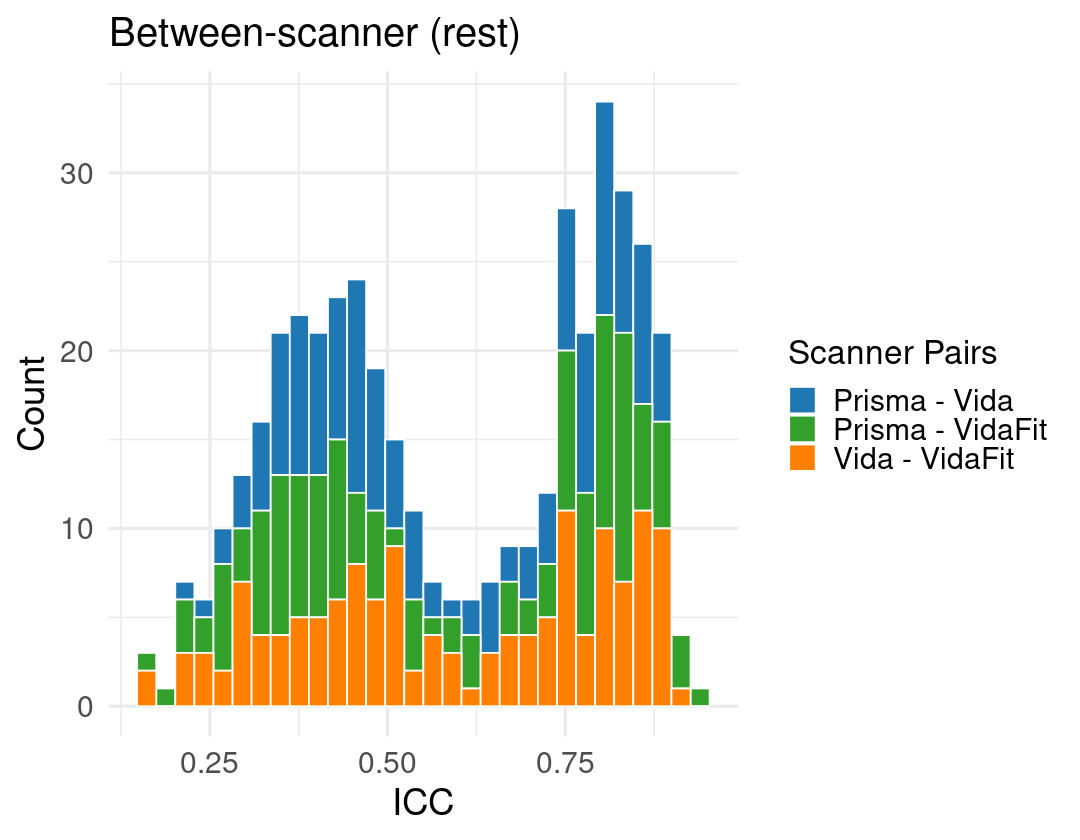

In [ ]:
#Plot the ICC distribution by scanner pairs
options(repr.plot.width = 9, repr.plot.height = 7)
ggplot(data = icc_between[is.na(icc_between$summary_statistic), ], aes(x = ICC, fill = scanner_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Scanner Pairs",
        title = "Between-scanner (rest)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20)
    ) +
    scale_fill_manual(values = c("#1F78B4", "#33A02C", "#FF7F00"))

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'iccVSscanner',
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300)

The three pairs of scanner exhibit a similar ICC distribution indicating that no scanner is an outlier in terms of reliability.

#### Did our participant consistently moved more in one scanner compared to the others? 

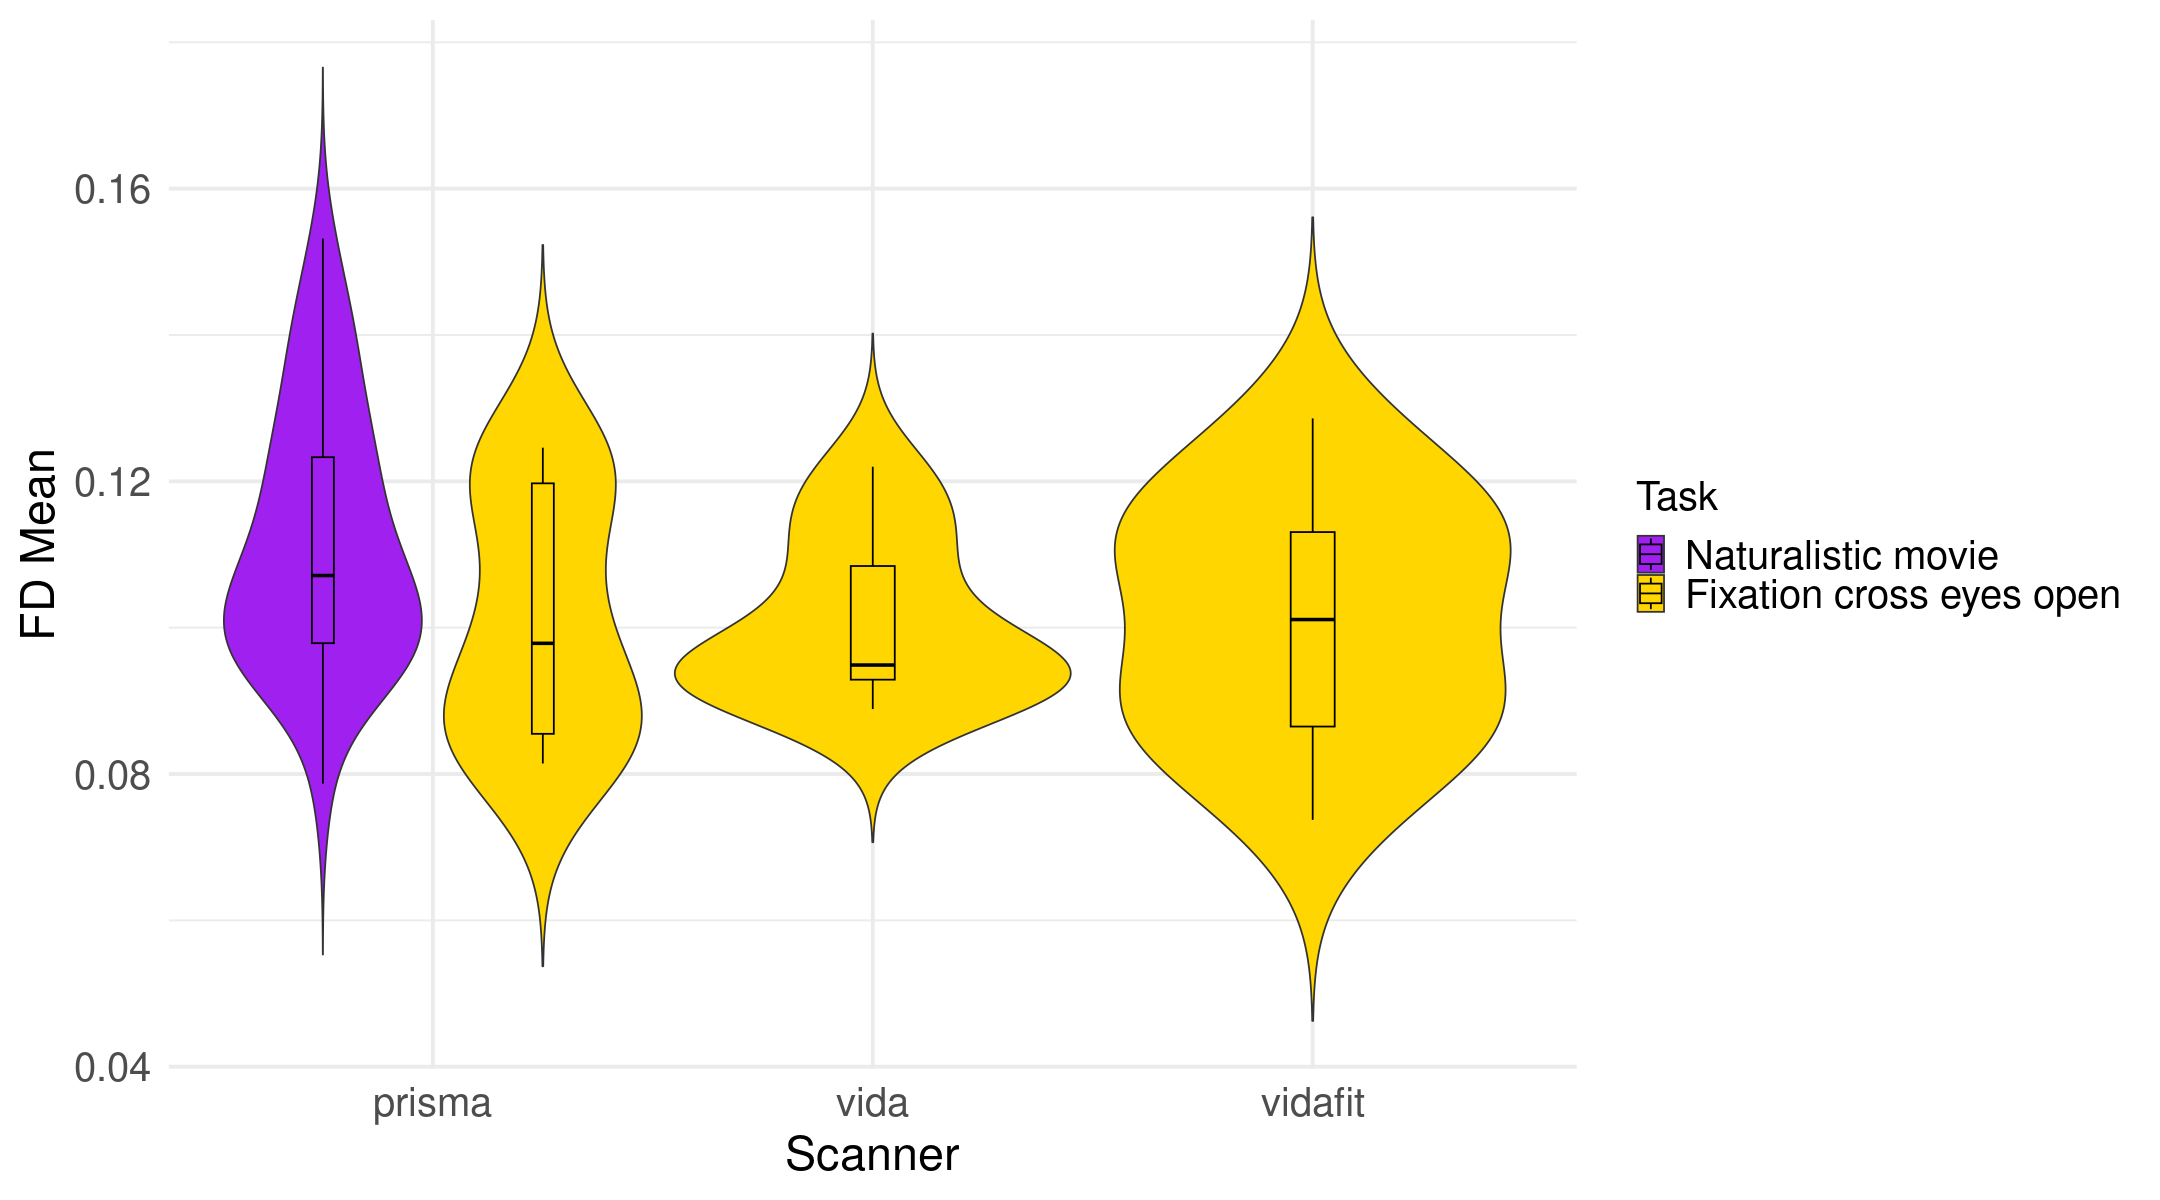

In [ ]:
# Prepare data for plotting
df_fc_plot <- df_fc %>%
    select(scanner, fd_mean) %>%
    mutate(task = "rest")


df_rsmovie_plot <- df_rsmovie %>%
    select(fd_mean) %>%
    mutate(task = "rsmovie")
df_rsmovie_plot["scanner"] <- "prisma" 

df_fd_plot <- bind_rows(df_fc_plot, df_rsmovie_plot)

df_fd_plot$scanner <- factor(df_fd_plot$scanner, levels = c("prisma", "vida", "vidafit"))
df_fd_plot$task <- factor(df_fd_plot$task, levels = c("rsmovie","rest"), labels = c("Naturalistic movie", "Fixation cross eyes open"))

# Plot violin plots
options(repr.plot.width = 18, repr.plot.height = 10)
plot <- ggplot(df_fd_plot, aes(x = scanner, y = fd_mean, fill = task)) +
    geom_violin(trim = FALSE, scale = "width", position = position_dodge(width = 1)) +
    geom_boxplot(width = 0.1, position = position_dodge(width = 1), outlier.shape = NA, color = "black") +
    labs(
        x = "Scanner",
        y = "FD Mean",
        fill = "Task",
    ) +
    theme_minimal(base_size = 24) +
    theme(
        axis.text.x = element_text(size = 24),
        axis.text.y = element_text(size = 24),
        axis.title.x = element_text(size = 28),
        axis.title.y = element_text(size = 28),
        legend.text = element_text(size = 24),
        legend.title = element_text(size = 24)
    ) +
    scale_fill_manual(values = c("purple", "#FFD600"))

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'FDvsScanner',
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300) 
print(plot)

In [ ]:
# Test for overall differences in FD mean across scanner-task combinations using Kruskal-Wallis test
fd_groups <- interaction(df_fd_plot$scanner, df_fd_plot$task, drop = TRUE)
kruskal_result <- kruskal.test(fd_mean ~ fd_groups, data = df_fd_plot)
print(kruskal_result)
# Perform posthoc pairwise comparisons using Dunn's test

dunn_result <- dunnTest(fd_mean ~ fd_groups, data = df_fd_plot, method = "bh")
print(dunn_result)


	Kruskal-Wallis rank sum test

data:  fd_mean by fd_groups
Kruskal-Wallis chi-squared = 7.2175, df = 3, p-value = 0.06528



Dunn (1964) Kruskal-Wallis multiple comparison

  p-values adjusted with the Benjamini-Hochberg method.




                                                          Comparison
1        prisma.Fixation cross eyes open - prisma.Naturalistic movie
2    prisma.Fixation cross eyes open - vida.Fixation cross eyes open
3          prisma.Naturalistic movie - vida.Fixation cross eyes open
4 prisma.Fixation cross eyes open - vidafit.Fixation cross eyes open
5       prisma.Naturalistic movie - vidafit.Fixation cross eyes open
6   vida.Fixation cross eyes open - vidafit.Fixation cross eyes open
            Z    P.unadj     P.adj
1 -1.92720121 0.05395456 0.1618637
2  0.04876714 0.96110487 0.9611049
3  1.98692852 0.04693032 0.2815819
4 -0.12679458 0.89910299 1.0000000
5  1.77191021 0.07640946 0.1528189
6 -0.17556172 0.86063828 1.0000000


There is no statistically significant difference in head motion between scanners nor between paradigms. In other words, unlike previous evidence showing that playing a movie reduced head motion compared to task-free fMRI (Greene et al. 2018; Finn 2021), our data shows the opposite trend with slightly (but non-significant) increase in FD when the movie was played. This also means that the difference in within-scanner reliability between the three scanners is not explained by difference in motion level.

#### Is motion or ICC consistently increasing over the repetition of the naturalistic movie?

,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,fd_mean,fd_diff,meas,slept_factor
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<fct>
1,within-scanner,rsmovie,prisma,1-2,0.8197148,NA,1,NA,0.10161056,0.020370927,correlation,Unknown
2,within-scanner,rsmovie,prisma,2-3,0.8087982,NA,0,NA,0.11507497,0.047299737,correlation,Unknown
3,within-scanner,rsmovie,prisma,3-4,0.8858683,NA,1,0,0.12171208,0.034025501,correlation,Slept in no session
4,within-scanner,rsmovie,prisma,4-5,0.8794863,NA,0,0,0.09169025,0.026018176,correlation,Slept in no session
5,within-scanner,rsmovie,prisma,5-6,0.8259917,NA,1,0,0.08723915,0.017115993,correlation,Slept in no session
6,within-scanner,rsmovie,prisma,6-7,0.7981182,NA,0,0,0.10068320,0.009772106,correlation,Slept in no session


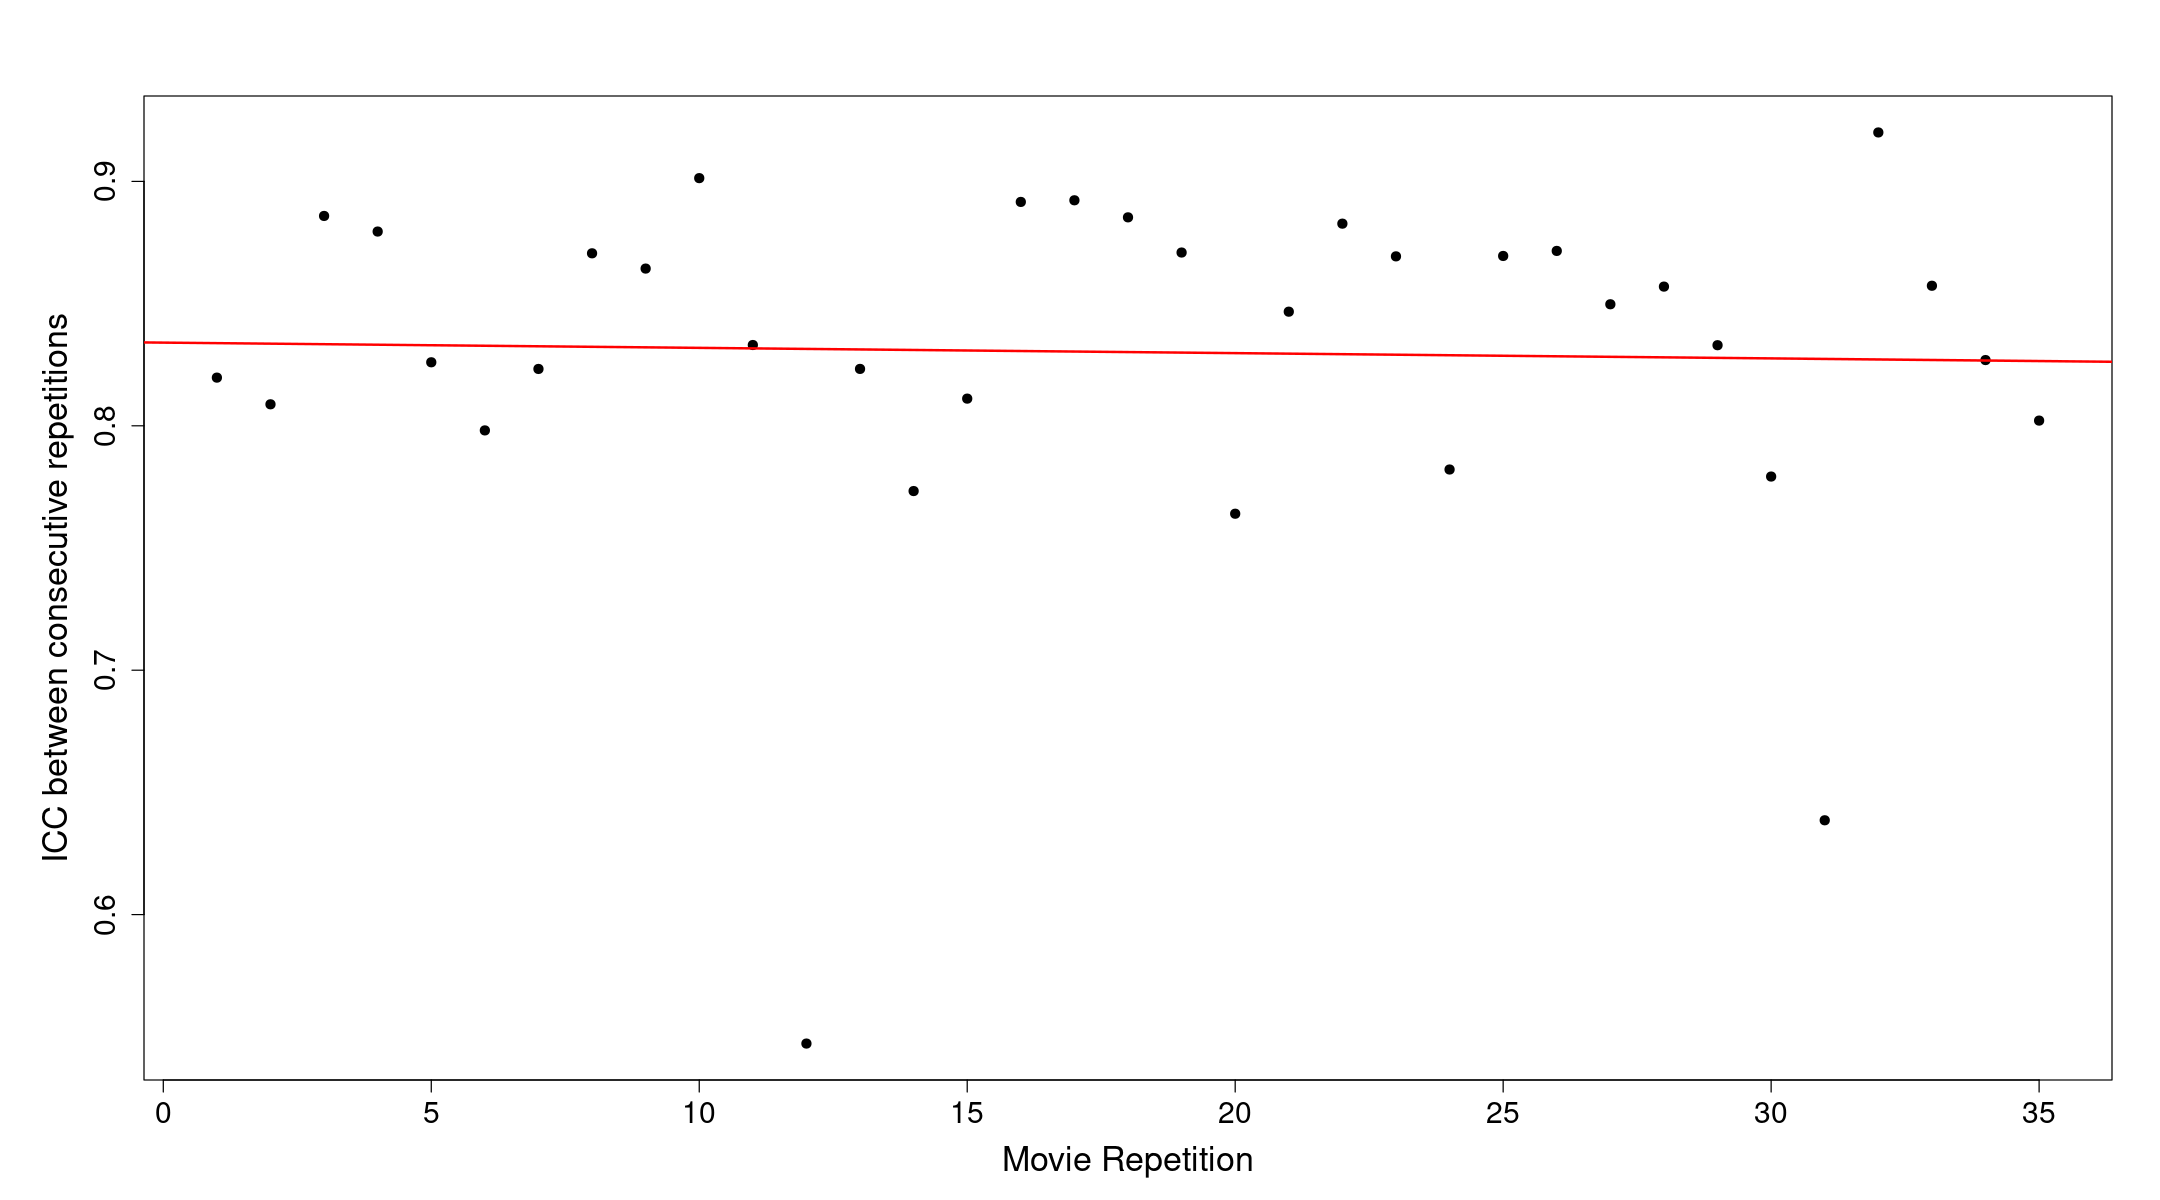

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 6)
icc_intra_rsmovie_consecutive <- icc_intra_rsmovie %>%
    filter(as.numeric(sub("-.*", "", repetition)) + 1 == as.numeric(sub(".*-", "", repetition)))
head(icc_intra_rsmovie_consecutive)
par(mar = c(5, 6, 4, 2))  # Increase left margin
plot(
    as.numeric(sub("-.*", "", icc_intra_rsmovie_consecutive$repetition)),
    icc_intra_rsmovie_consecutive$ICC,
    xlab = "Movie Repetition",
    ylab = "ICC between consecutive repetitions",
    pch = 19,
    col = "black",
    cex.axis = 1.5,  # Increase axis label size
    cex.lab = 1.7,   # Increase axis title size
    cex.main = 2     # Increase main title size (if added)
)
abline(lm(ICC ~ as.numeric(sub("-.*", "", repetition)), data = icc_intra_rsmovie_consecutive), col = "red", lwd = 2)

No, ICC does not increase with the movie repetition. This is consistent with the result of the fMRI variability analysis where we did not find an habituation effect to the movie (see `fmri-variability.ipynb`).

`geom_smooth()` using formula = 'y ~ x'


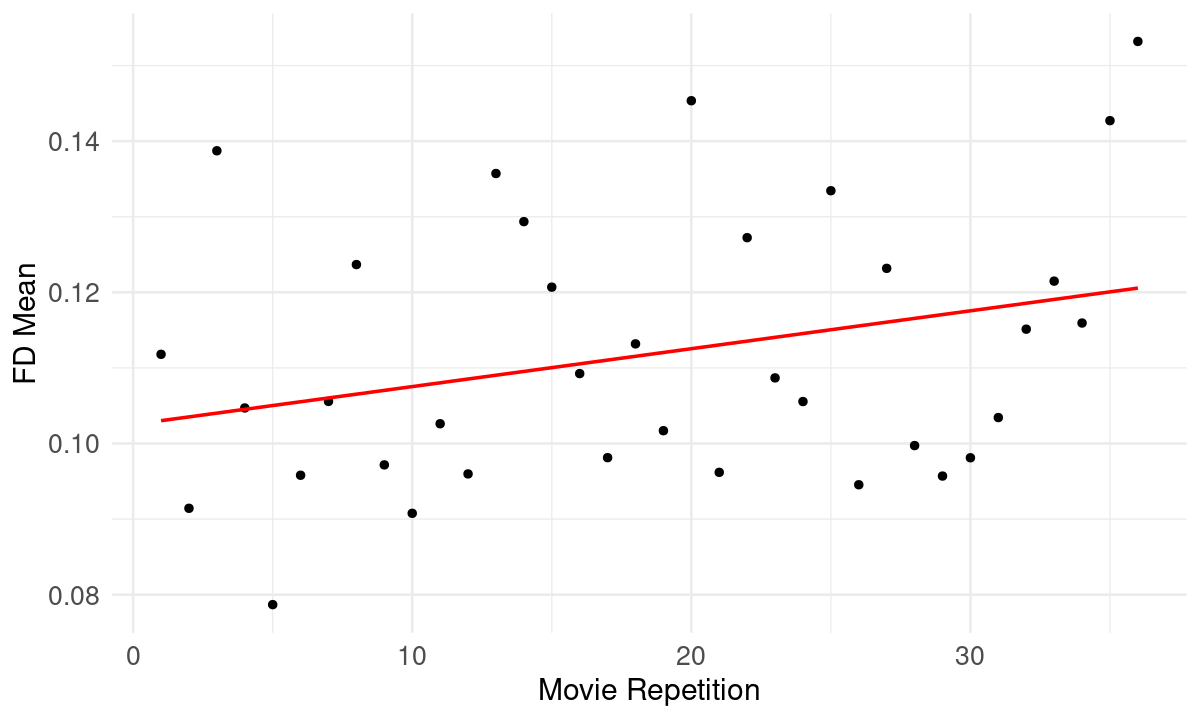

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 6)

ggplot(df_rsmovie, aes(x = repetition, y = fd_mean)) +
    geom_point(color = "black", size = 2) +
    geom_smooth(method = "lm", color = "red", lwd = 1, se = FALSE) +
    labs(
        x = "Movie Repetition",
        y = "FD Mean"
    ) +
    theme_minimal(base_size = 16) +
    theme(
        axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 18),
        axis.title.y = element_text(size = 18)
    )

Yes, mean framewise displacement increases over movie repetition.

#### Confound influence on ICC

ERROR: Error in data.frame(edge = edge_keys, ICC = icc_between$ICC, avg_strength = avg_edge_strength): arguments imply differing number of rows: 1891, 436


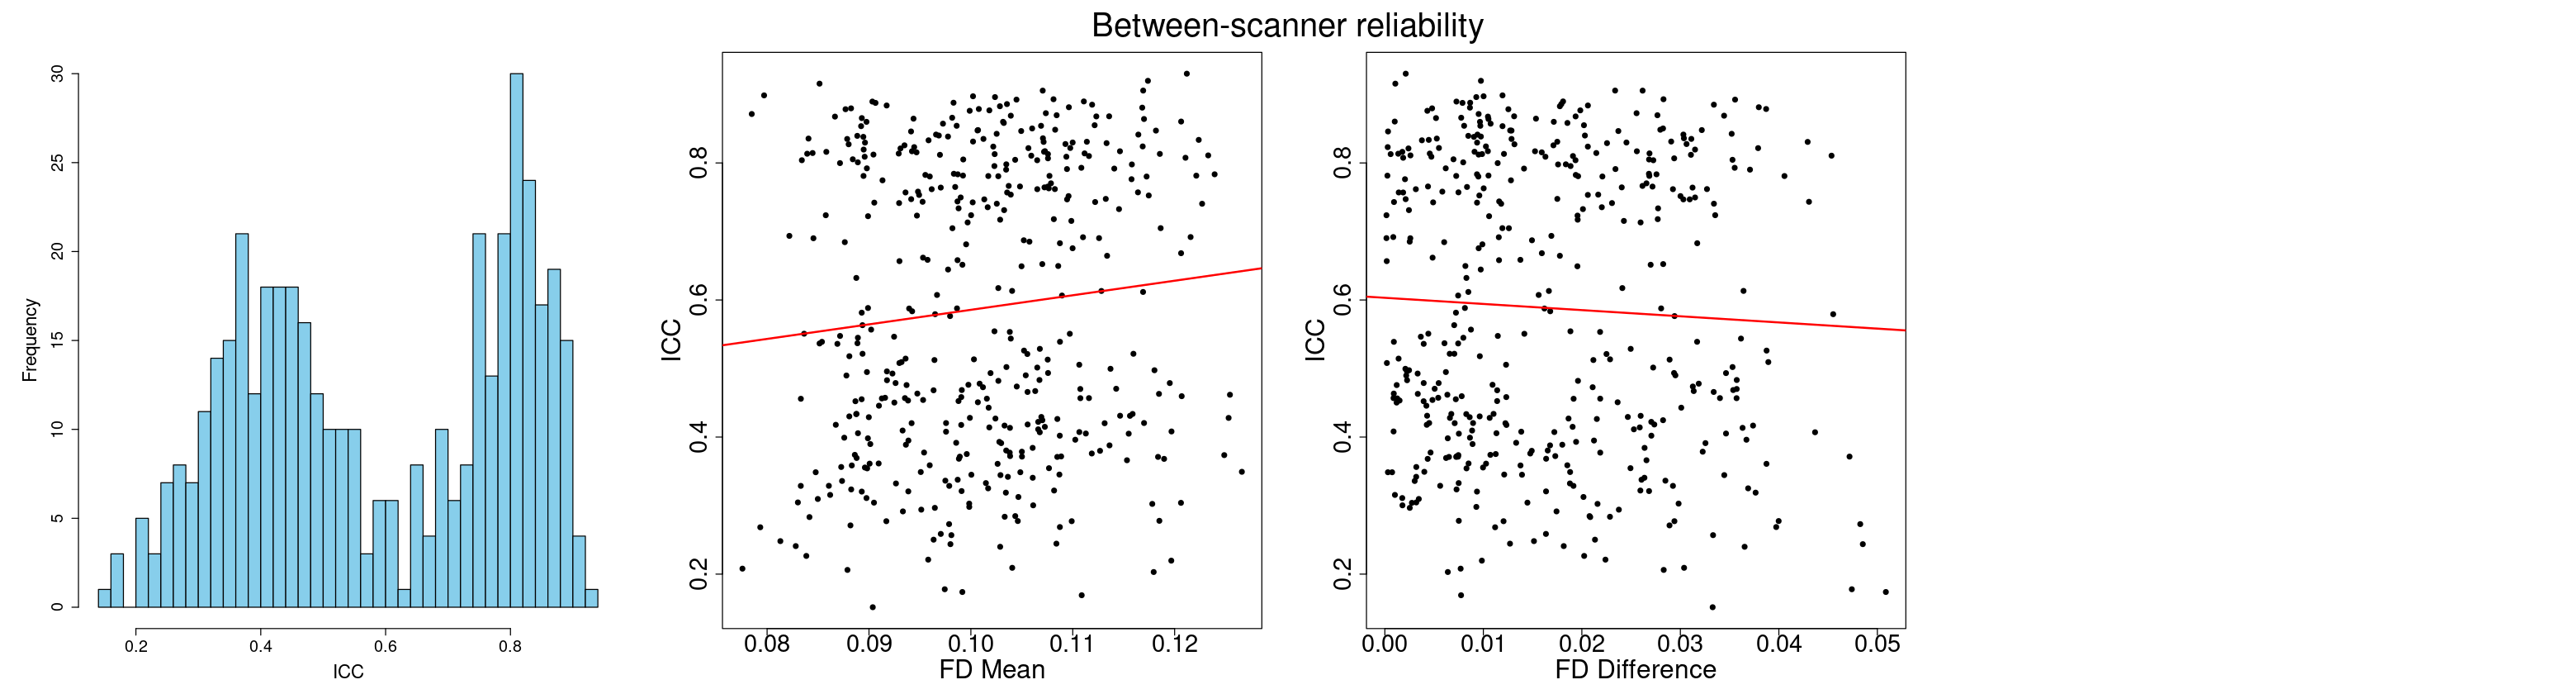

In [ ]:
options(repr.plot.width = 26, repr.plot.height = 7)
par(mfrow = c(1, 3), cex.axis = 2, cex.lab = 2, cex.main = 2, cex.sub = 2, mar = c(5, 6, 4, 2))  # Increase left margin

hist(
    icc_between$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    ylab = "Frequency",
    col = "skyblue",
    cex.axis = 1.5,
    cex.lab = 1.7,
    cex.main = 2
)
# Plot ICC vs FD mean
plot(
    icc_between$fd_mean, icc_between$ICC,
    xlab = "FD Mean",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_mean, data = icc_between), col = "red", lwd = 2)

# Plot ICC vs FD diff
plot(
    icc_between$fd_diff, icc_between$ICC,
    xlab = "FD Difference",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_diff, data = icc_between), col = "red", lwd = 2)
mtext("Between-scanner reliability", outer = TRUE, line = -3, cex = 2)
par(mfrow = c(1, 1))  # Reset plotting area

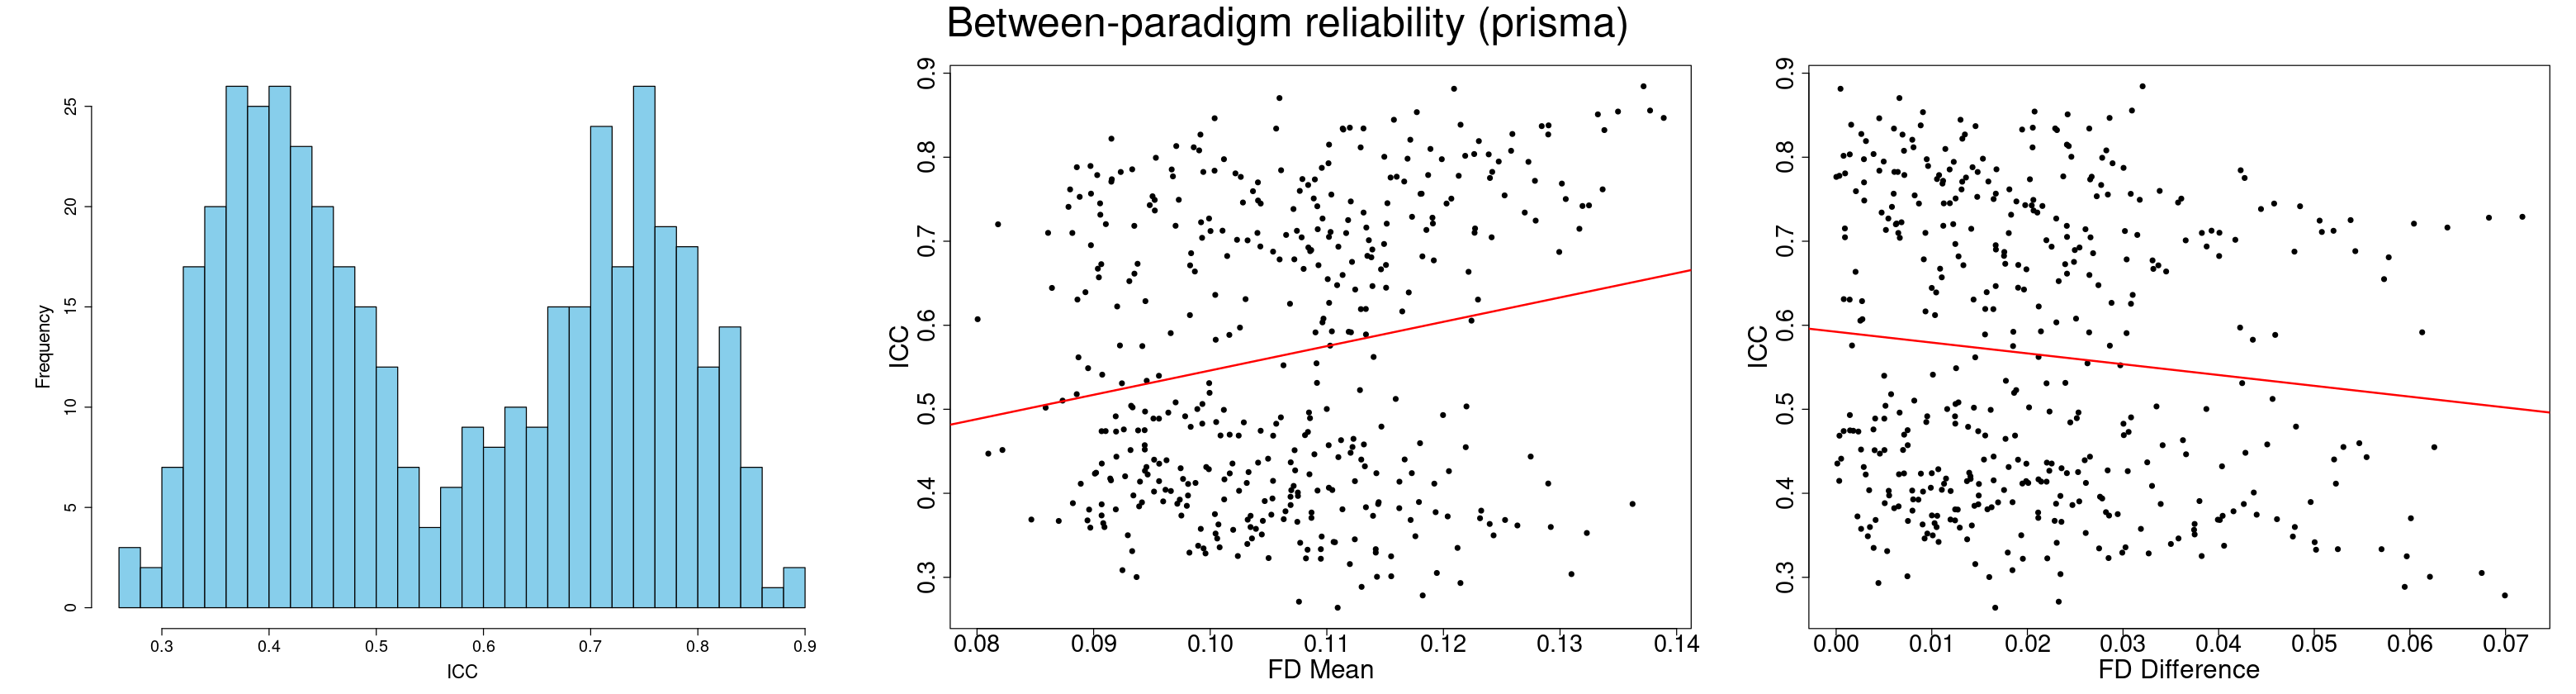

In [ ]:
options(repr.plot.width = 26, repr.plot.height = 7)
par(mfrow = c(1, 3), cex.axis = 2.2, cex.lab = 2.4, cex.main = 2.5, cex.sub = 2.2, mar = c(5, 7, 5, 2))  # Further increase font sizes
hist(
    icc_paradigm$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    ylab = "Frequency",
    col = "skyblue",
    cex.axis = 1.5,
    cex.lab = 1.7,
    cex.main = 2
)
# Plot ICC vs FD mean
plot(
    icc_paradigm$fd_mean, icc_paradigm$ICC,
    xlab = "FD Mean",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_mean, data = icc_paradigm), col = "red", lwd = 2)

# Plot ICC vs FD diff
plot(
    icc_paradigm$fd_diff, icc_paradigm$ICC,
    xlab = "FD Difference",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_diff, data = icc_paradigm), col = "red", lwd = 2)
mtext("Between-paradigm reliability (prisma)", outer = TRUE, line = -3, cex = 2.5)
par(mfrow = c(1, 1))  # Reset plotting area

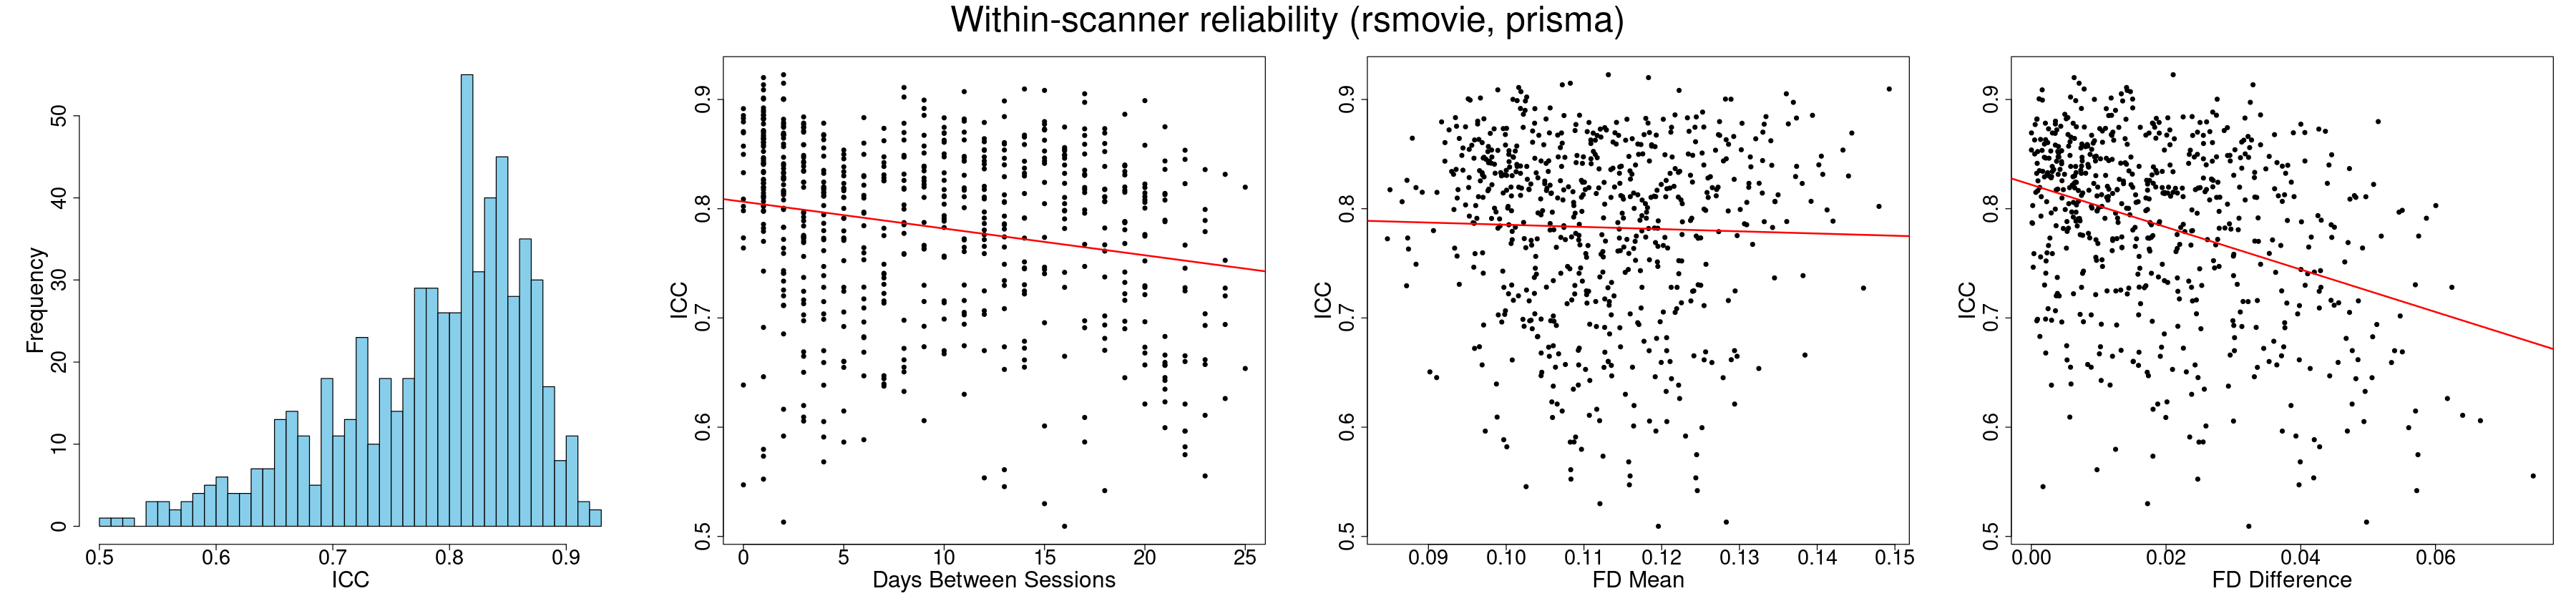

In [ ]:
# Make the plot wider by increasing the width of the plotting window and font sizes
options(repr.plot.width = 30, repr.plot.height = 7)
par(mfrow = c(1, 4), cex.axis = 2.2, cex.lab = 2.4, cex.main = 2.5, cex.sub = 2.2, mar = c(5, 7, 5, 2)) 
hist(
    icc_intra_rsmovie$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    col = "skyblue",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
plot(
    icc_intra_rsmovie$days_diff, icc_intra_rsmovie$ICC,
    xlab = "Days Between Sessions",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ days_diff, data = icc_intra_rsmovie), col = "red", lwd = 2)

# Plot ICC vs FD mean
plot(
    icc_intra_rsmovie$fd_mean, icc_intra_rsmovie$ICC,
    xlab = "FD Mean",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_mean, data = icc_intra_rsmovie), col = "red", lwd = 2)

# Plot ICC vs FD diff
plot(
    icc_intra_rsmovie$fd_diff, icc_intra_rsmovie$ICC,
    xlab = "FD Difference",
    ylab = "ICC",
    main = "",
    pch = 19,
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ fd_diff, data = icc_intra_rsmovie), col = "red", lwd = 2)
mtext("Within-scanner reliability (rsmovie, prisma)", outer = TRUE, line = -3, cex = 2.5)
par(mfrow = c(1, 1))  # Reset plotting area

When not censoring the high motion volumes (equivalent to setting a FD threshold of 10), the difference of mean FD between two sessions seems to have a significant effect on ICC, with ICC decreasing as the difference increases. 

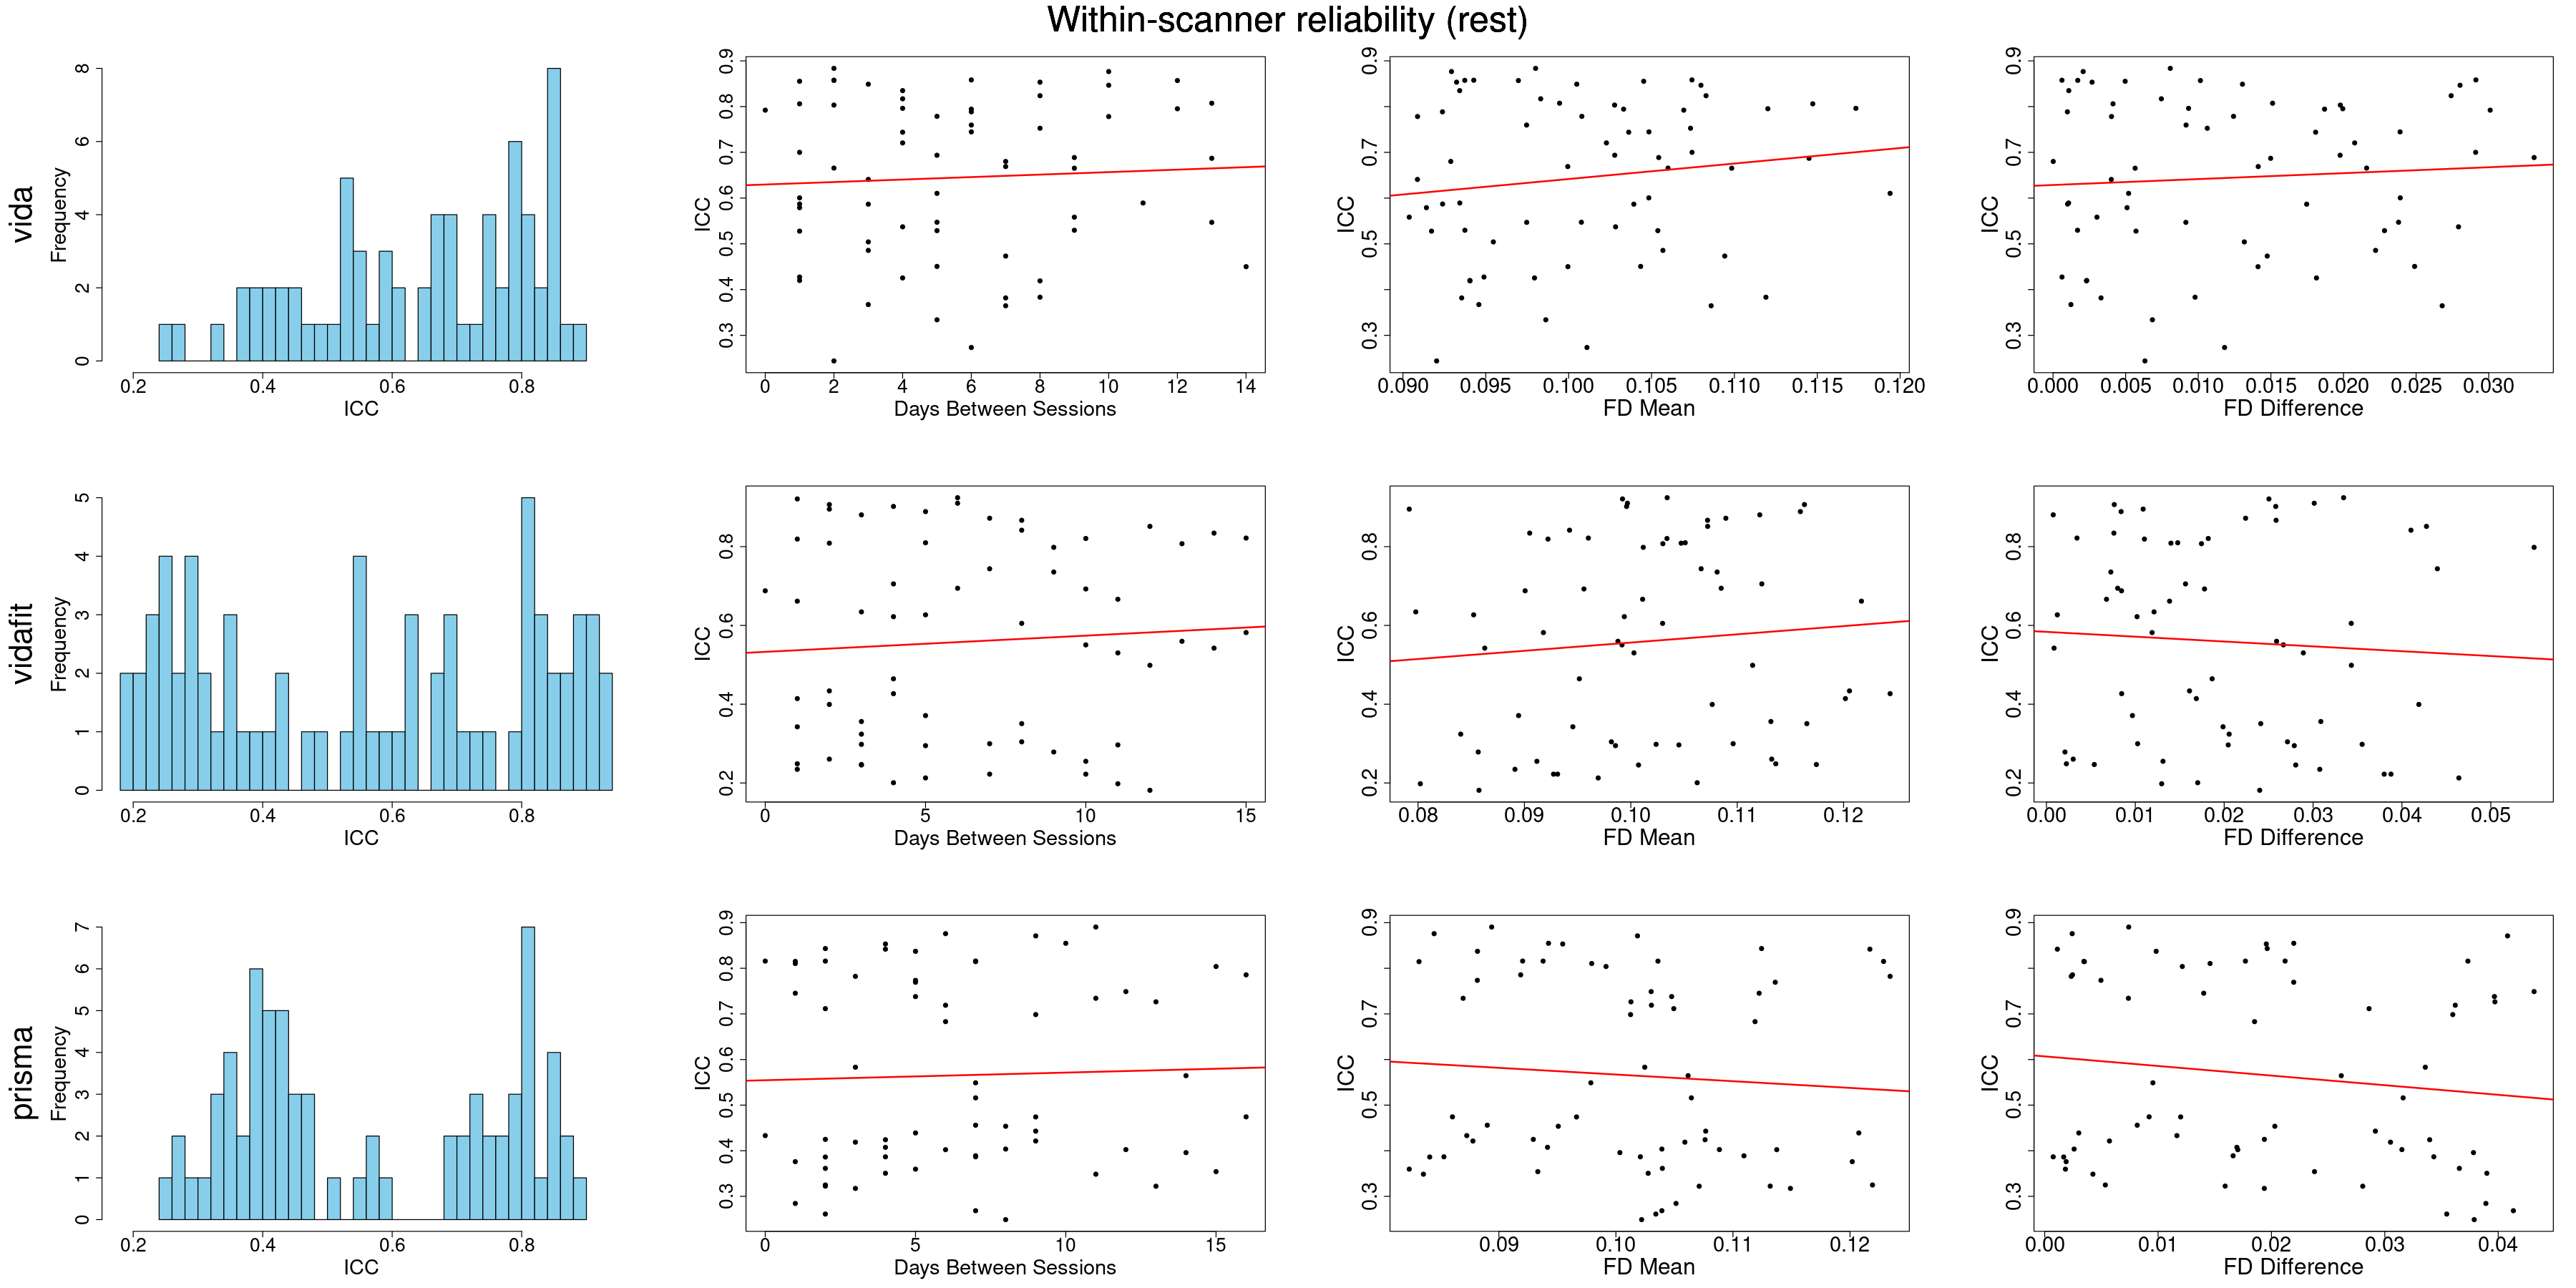

In [ ]:
options(repr.plot.width = 30, repr.plot.height = 15)
par(mfrow = c(3, 4), cex.axis = 2, cex.lab = 2.2, cex.main = 2.5, cex.sub = 2, mar = c(5, 9, 5, 2))  # Increase font sizes and margins

# Determine global x-axis limits for ICC
icc_range <- range(icc_intra_rest$ICC, na.rm = TRUE)

for (scanner in c("vida", "vidafit", "prisma")) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    mean_icc <- mean(icc_intra_rest_scanner$ICC, na.rm = TRUE)
    quantiles <- quantile(icc_intra_rest_scanner$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)   
    # Histogram with fixed xlim
    hist(
        icc_intra_rest_scanner$ICC,
        breaks = 30,
        xlab = "ICC",
        main = '',
        col = "skyblue",
        cex.axis = 2,
        cex.lab = 2.2,
        xlim = icc_range
    )
    mtext(scanner, side = 2, line = 6, cex = 2.2, las = 0)
    # Scatter plot: ICC vs days_diff
    plot(
        icc_intra_rest_scanner$days_diff, icc_intra_rest_scanner$ICC,
        xlab = "Days Between Sessions",
        ylab = "ICC",
        pch = 19,
        cex.axis = 2,
        cex.lab = 2.2
    )
    abline(lm(ICC ~ days_diff, data = icc_intra_rest_scanner), col = "red", lwd = 2)
    # Plot ICC vs FD mean
    plot(
        icc_intra_rest_scanner$fd_mean, icc_intra_rest_scanner$ICC,
        xlab = "FD Mean",
        ylab = "ICC",
        main = "",
        pch = 19,
        cex.axis = 2.2,
        cex.lab = 2.4,
        cex.main = 2.5
    )
    abline(lm(ICC ~ fd_mean, data = icc_intra_rest_scanner), col = "red", lwd = 2)

    # Plot ICC vs FD diff
    plot(
        icc_intra_rest_scanner$fd_diff, icc_intra_rest_scanner$ICC,
        xlab = "FD Difference",
        ylab = "ICC",
        main = "",
        pch = 19,
        cex.axis = 2.2,
        cex.lab = 2.4,
        cex.main = 2.5
    )
    abline(lm(ICC ~ fd_diff, data = icc_intra_rest_scanner), col = "red", lwd = 2)
    mtext("Within-scanner reliability (rest)", outer = TRUE, line = -3, cex = 2.5)
}
par(mfrow = c(1, 1))  # Reset plotting area

## Compute edge-specific ICC

Earlier in the notebook, we used edges as "subjects" and different condition (scanner, paradigm ,session) as "raters". 

To compare with the ICC estimates from Nakuci et al. 2023, let us now generate edge-wise ICC using repetitions of a single edge estimate as "subjects" and condition as "raters".

### Between-scanner

In [ ]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Iterate over all edges
col_names <- colnames(df_fc)
#Remove non-iqms column names
edge_keys <- col_names[grepl("^edge", col_names)]
if (any(!grepl("^edge", edge_keys))) {
    stop("All elements in edge_keys must contain 'edge'")
}
for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_fc[, c( "scanner", edge)]
    df_icc <- pivot_wider(df_icc, names_from = scanner, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(prisma, vida, vidafit))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
df_icc
head(icc_vals)

prisma,vidafit,vida
<dbl>,<dbl>,<dbl>
0.3620068,0.5189680,0.5960710
0.4216522,0.5300936,0.6179405
0.3304195,0.5457828,0.5529241
0.5405864,0.3387351,0.3527906
0.5553758,0.6012507,0.3855313
0.5059431,0.5073618,0.4913253
0.4990836,0.5287183,0.5088774
0.6696954,0.5441925,0.5725760
0.4960707,0.5386495,0.6626793


,edge,ICC
,<chr>,<dbl>
1,edge1,0.05878540
2,edge2,0.07420592
3,edge3,-0.02879484
4,edge4,-0.34783099
5,edge5,-0.07901565
6,edge6,-0.10314388


Mean between-scanner variability quantified as ICC across edges: -0.05502567 
Median ICC across edges: -0.07998961 


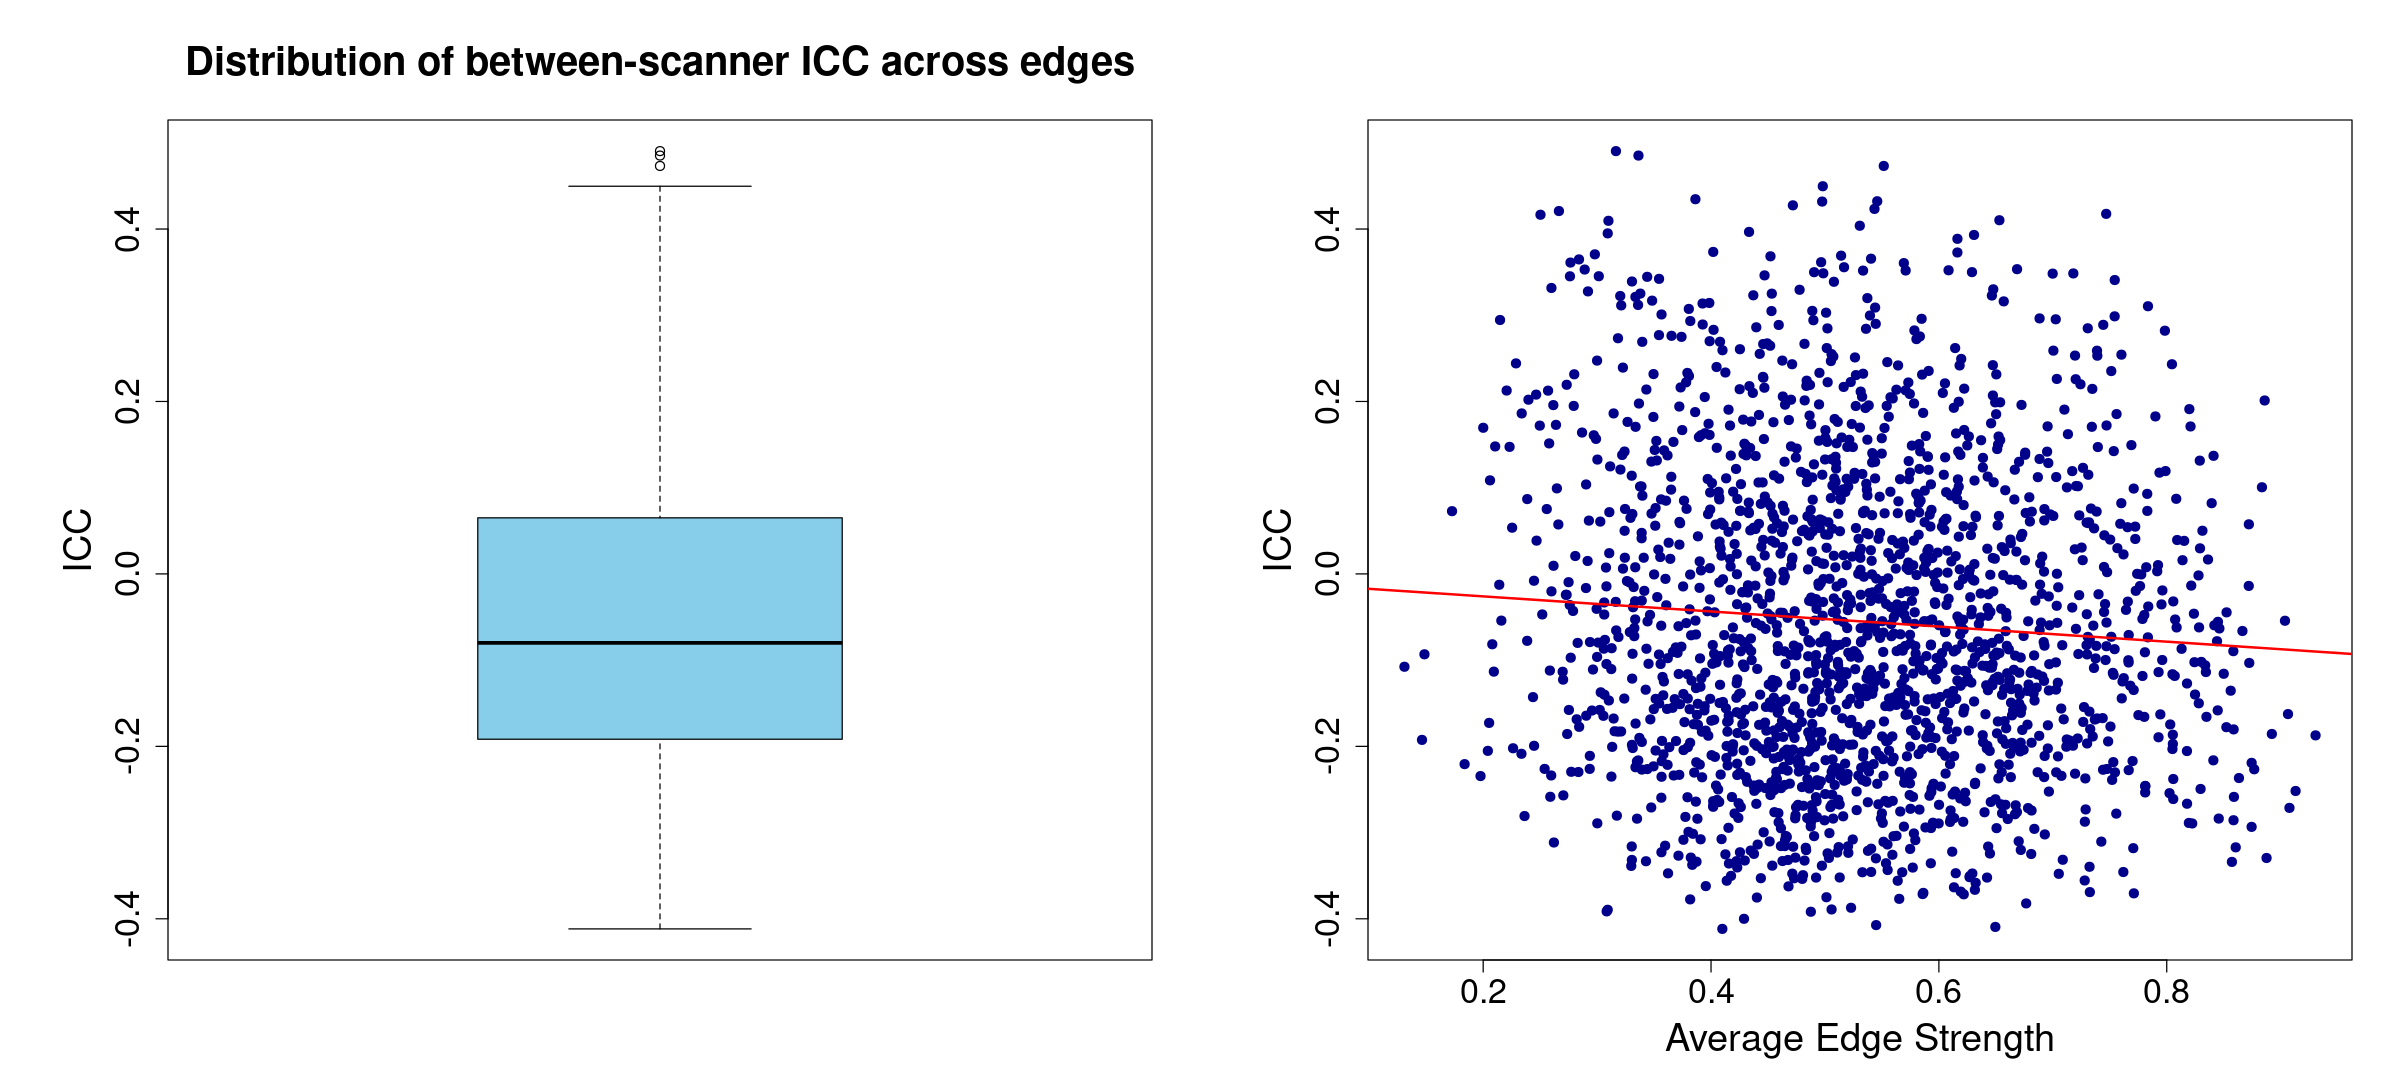

In [ ]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean between-scanner variability quantified as ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_vals$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

# Calculate average edge strength across all sessions for each edge
avg_edge_strength <- sapply(edge_keys, function(edge) mean(df_fc[[edge]], na.rm = TRUE))

# Merge ICC values and average edge strength into a data frame
icc_vs_strength <- data.frame(
    edge = edge_keys,
    ICC = icc_vals$ICC,
    avg_strength = avg_edge_strength
)

# Plot
options(repr.plot.width = 20, repr.plot.height = 9)
par(mfrow = c(1, 2), cex.axis = 1.7, cex.lab = 1.9, cex.main = 2.0, cex.sub = 2.2, mar = c(5, 7, 5, 2))

boxplot(icc_vals$ICC, main = "Distribution of between-scanner ICC across edges", ylab = "ICC", col = "skyblue")

# Plot ICC versus average edge strength
plot(
    icc_vs_strength$avg_strength, icc_vs_strength$ICC,
    xlab = "Average Edge Strength",
    ylab = "ICC",
    pch = 19, col = "darkblue"
)
abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)

Similarly to Nakuci et al. 2023, the estimate of edge-wise between-scanner reliability is centered around zero.

### Intra-scanner

Warning message in qf(1 - alpha/2, v, ns - 1):
“qbeta(a, *) =: x0 with |pbeta(x0,*) - alpha| = 0.0080681 is not accurate”


Mean within-scanner variability quantified as ICC across edges for scanner prisma : 0.06240749 
Median ICC across edges for scanner prisma : 0.04525968 
Mean within-scanner variability quantified as ICC across edges for scanner vida : 0.09044205 
Median ICC across edges for scanner vida : 0.08167392 
Mean within-scanner variability quantified as ICC across edges for scanner vidafit : -0.0362435 
Median ICC across edges for scanner vidafit : -0.05126385 


0.5189680,0.5300936,0.5457828
0.3387351,0.6012507,0.5073618
0.5287183,0.5441925,0.5386495
0.4370343,0.4344734,0.2901794


,edge,ICC
,<chr>,<dbl>
1,edge1,0.56988005
2,edge2,-0.52738900
3,edge3,-0.01642215
4,edge4,-0.73597936
5,edge5,-0.26494963
6,edge6,-0.10664687


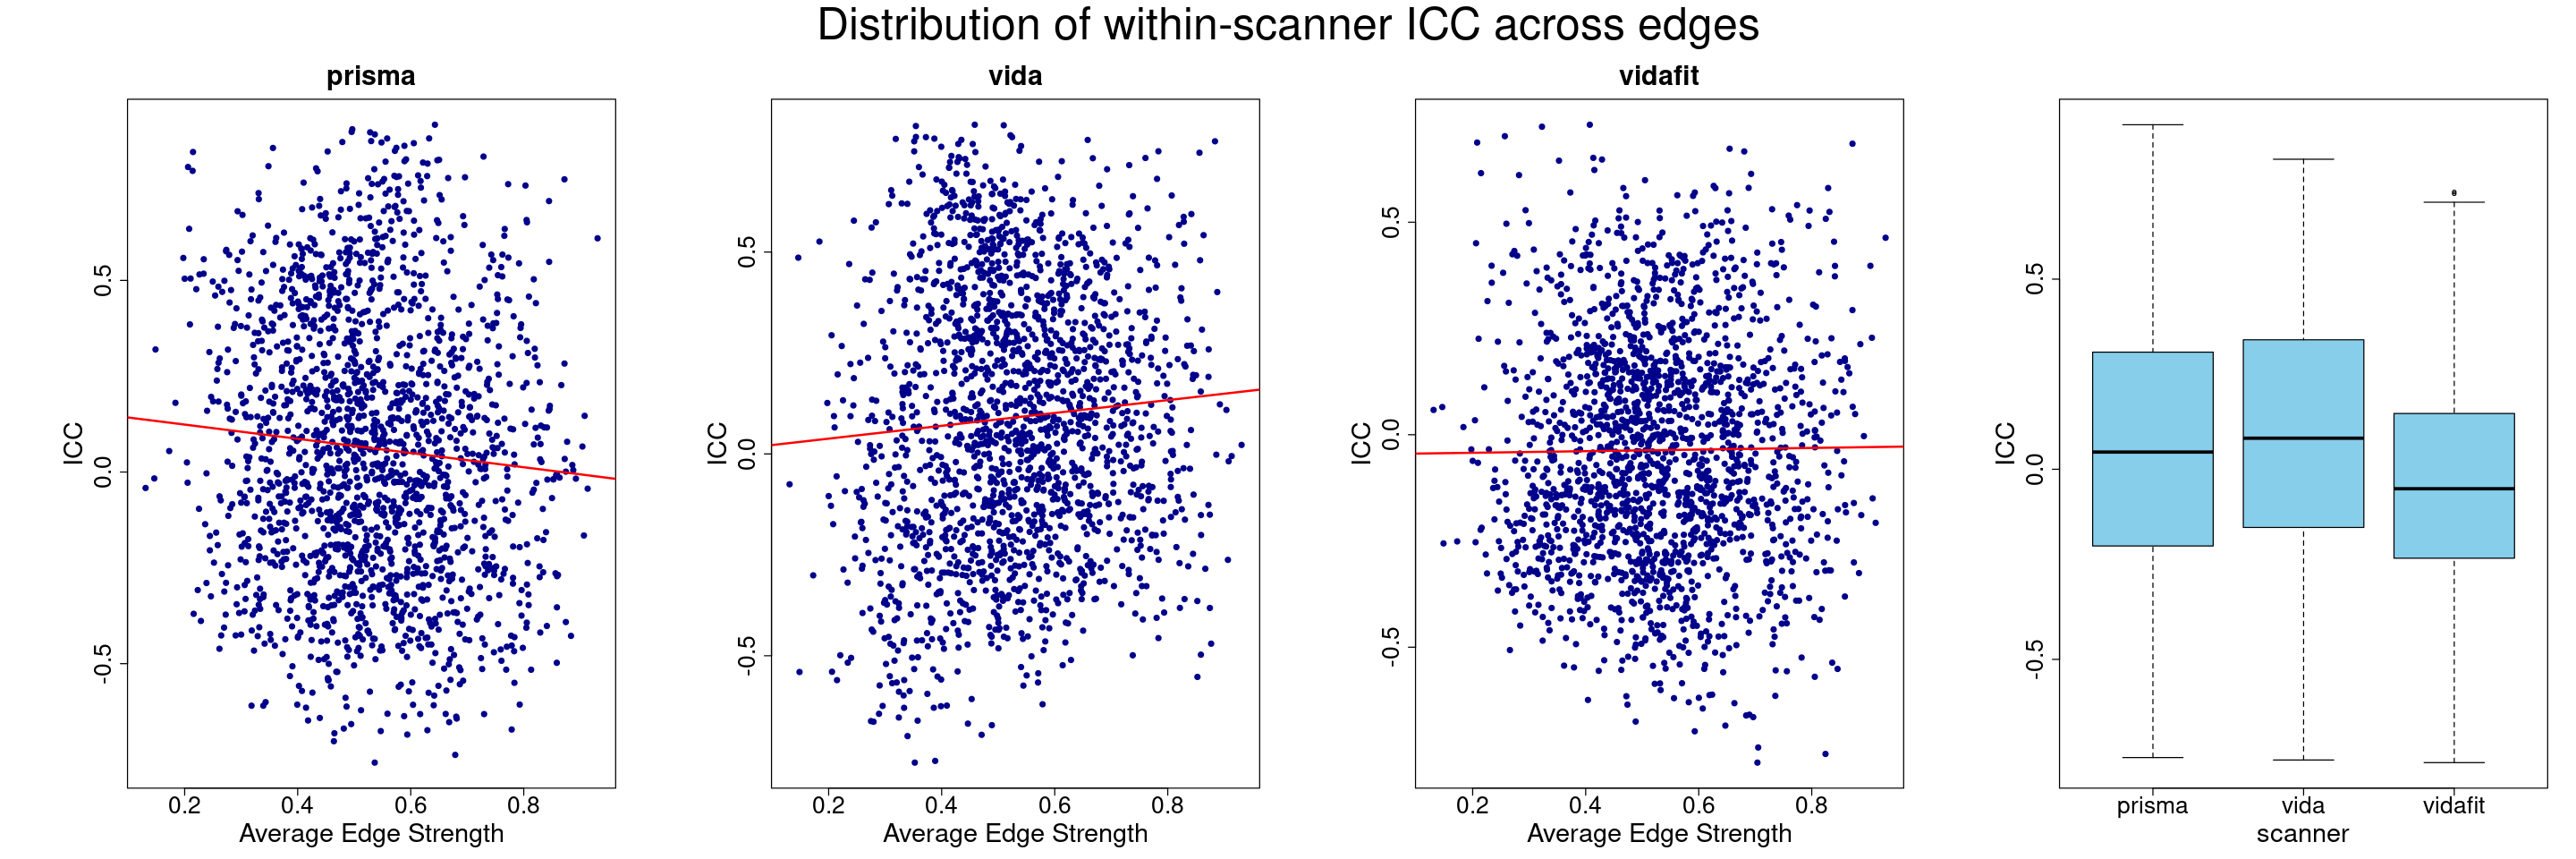

In [ ]:
options(repr.plot.width = 24, repr.plot.height = 8)
par(mfrow = c(1, 4), cex.axis = 2.0, cex.lab = 2.2, cex.main = 2.3, cex.sub = 2.2, mar = c(5, 9, 7, 2))
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Iterate over all edges
for (scanner in c("prisma", "vida", "vidafit")) {
    df_fc_scanner <- df_fc[df_fc$scanner == scanner, ]
    icc_vals_scanner <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)
    for (edge in edge_keys) {
        # Keep only the edge and session columns
        df_icc <- as.matrix(df_fc_scanner[, edge])
        # Reshape the 1x12 dataframe to 4x3 in other words, match trios of sessions as different "raters" to estimate within-scanner reliability
        df_icc <- matrix(df_icc, nrow = 4, ncol = 3, byrow = TRUE)
        # Compute ICC(2,1) for this edge
        icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
        icc_vals_scanner <- rbind(icc_vals_scanner, data.frame(edge = edge, ICC = icc_val))
    }
    mean_icc_scanner <- mean(icc_vals_scanner$ICC, na.rm = TRUE)
    cat("Mean within-scanner variability quantified as ICC across edges for scanner", scanner, ":", mean_icc_scanner, "\n")
    median_icc_scanner <- median(icc_vals_scanner$ICC, na.rm = TRUE)
    cat("Median ICC across edges for scanner", scanner, ":", median_icc_scanner, "\n")

    # Merge ICC values and average edge strength into a data frame
    icc_vs_strength <- data.frame(
        edge = edge_keys,
        ICC = icc_vals_scanner$ICC,
        avg_strength = avg_edge_strength
    )

    # Store ICC values for each scanner in a list for combined plotting
    if (!exists("icc_vals_list")) icc_vals_list <- list()
    icc_vals_list[[scanner]] <- icc_vals_scanner

    # Plot
    plot(
        icc_vs_strength$avg_strength, icc_vs_strength$ICC,
        xlab = "Average Edge Strength",
        ylab = "ICC",
        pch = 19, col = "darkblue",
    )
    title(main = scanner, line = 1)
    abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)
    }
# Plot boxplots for all scanners on the same plot
# Combine ICC values from all scanners into a single data frame for boxplot
icc_vals_all <- do.call(rbind, lapply(names(icc_vals_list), function(scanner) {
    data.frame(scanner = scanner, ICC = icc_vals_list[[scanner]]$ICC)
}))

boxplot(ICC ~ scanner, data = icc_vals_all, ylab = "ICC", col = "skyblue")
mtext("Distribution of within-scanner ICC across edges", outer = TRUE, line = -3, cex = 2.5)
df_icc
head(icc_vals_scanner)

Similarly to Nakuci et al. 2023, our distribution of within-scanner edge-wise ICC is centered close to 0.0-0.1. But unlike their result, we do not really observe an increase of reliability with a higher edge strength; this might be due to the fact that many ICC here are estimated as negative (but not in Nakuci's results). Negative ICC are artifactual and may arise when variance components are inadvertendly estimated to be negative, often due to the use of a small nbr of sample relative to the variability in the dataset.

### Between-paradigm

In [ ]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Randomly select 12 sessions from the rsmovie task because we need to have the same number of sessions for each task to be able to compute ICC
selected_sessions <- sample(unique(df_fc_paradigm$repetition[df_fc_paradigm$task == "rsmovie"]), 12)
df_paradigm <- df_fc_paradigm[df_fc_paradigm$repetition %in% selected_sessions | df_fc_paradigm$task == "rest", ]

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_paradigm[, c( "task", edge)]
    df_icc <- pivot_wider(df_icc, names_from = task, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(rest, rsmovie))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
df_icc
head(icc_vals)

rest,rsmovie
<dbl>,<dbl>
0.3620068,0.6935908
0.4216522,0.7270293
0.3304195,0.5806219
0.5405864,0.6863294
0.5553758,0.6034674
0.5059431,0.5906190
0.4990836,0.6043138
0.6696954,0.5807538
0.4960707,0.6330315


,edge,ICC
,<chr>,<dbl>
1,edge1,-0.2262572
2,edge2,-0.2554171
3,edge3,-0.4412481
4,edge4,-0.1864126
5,edge5,-0.2629739
6,edge6,-0.1974204


Mean between-paradigm ICC across edges: -0.02491936 
Median ICC across edges: -0.02279257 


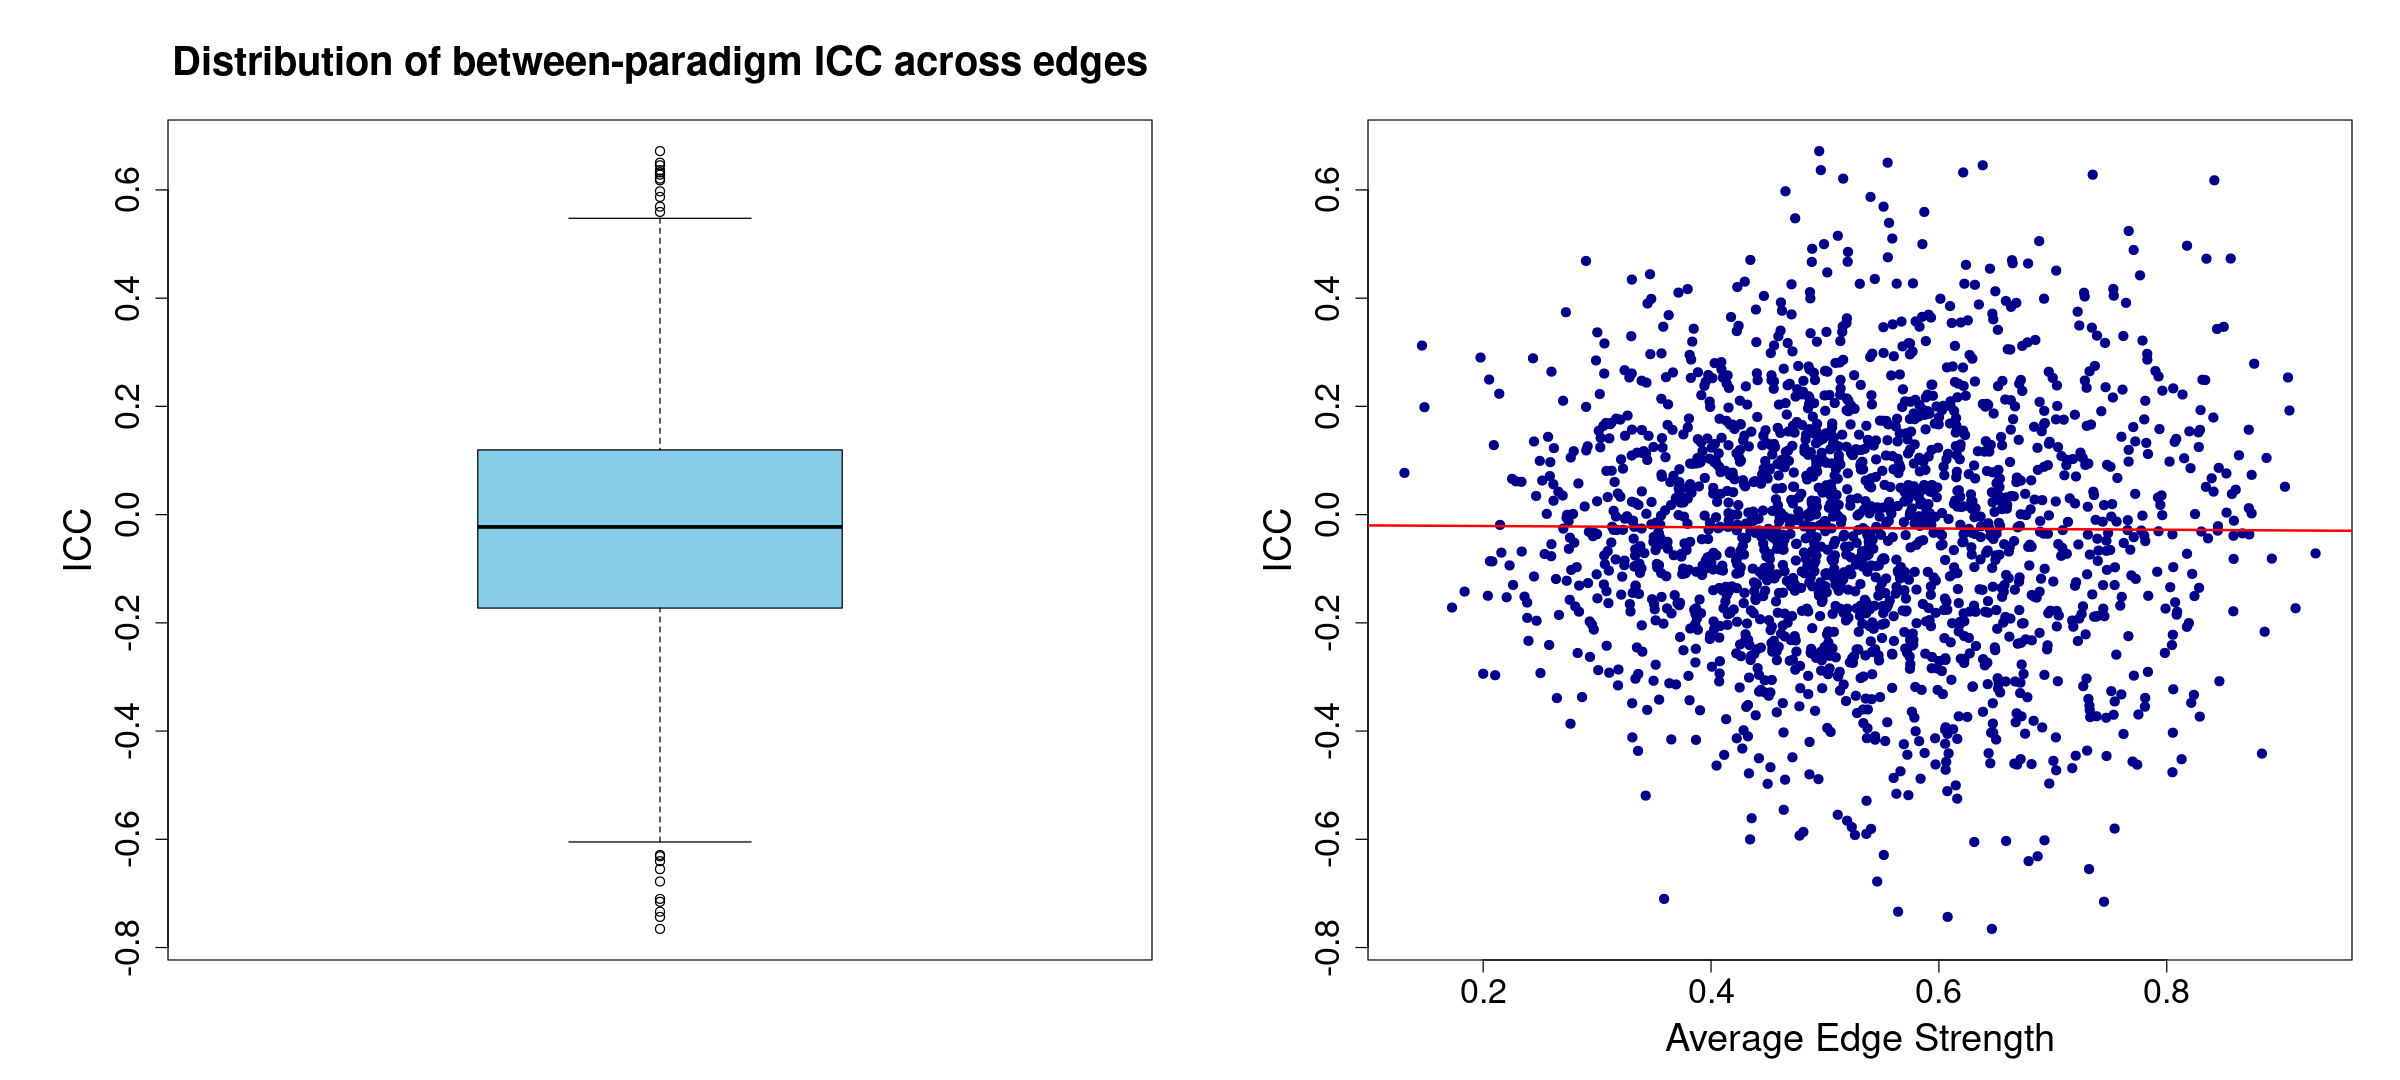

In [ ]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean between-paradigm ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_vals$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

# Merge ICC values and average edge strength into a data frame
icc_vs_strength <- data.frame(
    edge = edge_keys,
    ICC = icc_vals$ICC,
    avg_strength = avg_edge_strength
)

# Plot
options(repr.plot.width = 20, repr.plot.height = 9)
par(mfrow = c(1, 2), cex.axis = 1.7, cex.lab = 1.9, cex.main = 2.0, cex.sub = 2.2, mar = c(5, 7, 5, 2))

boxplot(icc_vals$ICC, main = "Distribution of between-paradigm ICC across edges", ylab = "ICC", col = "skyblue")

# Plot ICC versus average edge strength
plot(
    icc_vs_strength$avg_strength, icc_vs_strength$ICC,
    xlab = "Average Edge Strength",
    ylab = "ICC",
    pch = 19, col = "darkblue"
)
abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)

# References

- Greene, Deanna J., Jonathan M. Koller, Jacqueline M. Hampton, et al. 2018. “Behavioral Interventions for Reducing Head Motion during MRI Scans in Children.” NeuroImage 171 (May): 234–45. https://doi.org/10.1016/j.neuroimage.2018.01.023.
- Finn, Emily S. 2021. “Is It Time to Put Rest to Rest?” Trends in Cognitive Sciences 25 (12): 1021–32. https://doi.org/10.1016/j.tics.2021.09.005.
- Nakuci, Johan, Nick Wasylyshyn, Matthew Cieslak, et al. 2023. “Within-Subject Reproducibility Varies in Multi-Modal, Longitudinal Brain Networks.” Scientific Reports 13 (1): 6699. https://doi.org/10.1038/s41598-023-33441-3.
